# Région convective : covariance $u'w'$ et comparaison à Romps (2014)

**Deux objectifs.**

1. **Comprendre la covariance de la région convective.** D'où vient $\overline{u'w'}$ ? À quels
   niveaux est-elle grosse, et pourquoi ? On la décompose par catégorie (up / dn / env) et on la
   visualise par scatterplots $(u',w')$ pour distinguer ce qui relève d'un *transport organisé*
   (séparation des moyennes entre catégories) de ce qui relève d'une *corrélation interne*.

2. **Comparer ma modélisation à celle de Romps (2014).** Point méthodologique central, soulevé
   à la relecture : **il est faux de comparer le flux de Reynolds *total* au seul flux de masse
   *montant*.** Le flux de masse, en tant que quantité conservative, met en jeu *tous* les
   courants (montant, descendant, environnement) dont les flux de masse se compensent
   ($\sum_k\sigma_k\bar w_k=0$). Cette partie repart donc sur des bases correctes : on écrit le
   flux de masse complet, on situe précisément ce que Romps néglige (les descendances) et ce
   qu'il garde (la subsidence compensatoire de l'environnement), puis on confronte les deux
   cadres.

---
**Acquis des notebooks précédents (non re-démontré ici).** La décomposition exacte
$\Phi_{rey}=T_1(\text{organisé})+T_2(\text{sous-maille})$ ferme le budget au zéro machine, avec
$T_1\sim56\,\%$, $T_2\sim44\,\%$. On part de là pour *expliquer* et *comparer*, pas pour
re-prouver l'identité.

## 0 — Setup commun

On recharge la grille Méso-NH `large300`, l'état stationnaire (`t_stat`), les masques
humide/sec (PRW) et la densité de référence $\rho_0(z)$. **Toute l'analyse porte sur la région
humide**, où la convection profonde domine.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import xarray as xr
import gc, os

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

Rd, Rv = 287.05, 461.5
EPSILON = Rd / Rv
DIR_3D, DIR_2D, DIR_1D = '3D', '2D', '1D'
def path3d(v): return os.path.join(DIR_3D, f'MESONH_RCE_large300_3D_{v}.nc')
def path2d(v): return os.path.join(DIR_2D, f'MESONH_RCE_large300_2D_{v}.nc')
def path1d(v): return os.path.join(DIR_1D, f'MESONH_RCE_large300_1D_{v}.nc')
print('Pret.')

Pret.


In [27]:
# --- dimensions + altitude ---
_ds = xr.open_dataset(path3d('ua')); _da = _ds['ua']
dim_t, dim_z, dim_y, dim_x = _da.dims[:4]
n_t, n_z = _da.sizes[dim_t], _da.sizes[dim_z]
_ds.close(); del _ds, _da; gc.collect()

_ds1 = xr.open_dataset(path1d('ua_avg'))
alt  = _ds1.altitude.values.copy()
_ds1.close(); del _ds1; gc.collect()

t_stat = int(2*n_t/3)
print(f'{n_t} t x {n_z} z   |  altitude {alt[0]:.0f}-{alt[-1]:.0f} m   |  t_stat={t_stat}')

100 t x 74 z   |  altitude 0-32500 m   |  t_stat=66


In [3]:
# --- masques humide/sec via PRW ---
ds_prw  = xr.open_dataset(path2d('prw'))
prw_all = ds_prw['prw'].load(); ds_prw.close()
prw_mean  = prw_all.isel({dim_t: slice(t_stat,None)}).mean(dim=dim_t)
PRW_SEUIL = float(np.median(prw_all.values.ravel()))
mh = (prw_mean.values > PRW_SEUIL); ms = ~mh
f_h, f_s = mh.mean(), ms.mean()
del prw_all; gc.collect()
print(f'Humide {f_h*100:.1f}%   Sec {f_s*100:.1f}%')

Humide 42.3%   Sec 57.7%


In [4]:
# --- densite de reference rho0(z) ---
BLOC = 2
rho0_sum = np.zeros(n_z); n_rho = 0
ds_ta = xr.open_dataset(path3d('ta')); ds_pa = xr.open_dataset(path3d('pa')); ds_hus = xr.open_dataset(path3d('hus'))
for t0 in range(t_stat, n_t, BLOC):
    t1 = min(t0+BLOC, n_t); sl = {dim_t: slice(t0,t1)}
    T  = ds_ta['ta'].isel(sl).values; p = ds_pa['pa'].isel(sl).values; qv = ds_hus['hus'].isel(sl).values
    Tv = T*(1+qv/EPSILON)/(1+qv); rho = p/(Rd*Tv)
    rho0_sum += rho.mean(axis=(0,2,3))*(t1-t0); n_rho += (t1-t0)
    del T,p,qv,Tv,rho; gc.collect()
ds_ta.close(); ds_pa.close(); ds_hus.close(); del ds_ta,ds_pa,ds_hus; gc.collect()
rho0 = rho0_sum/n_rho
print(f'rho0 surface {rho0[0]:.3f}  ~10km {rho0[np.argmin(np.abs(alt-10000))]:.3f} kg/m3')

rho0 surface 1.183  ~10km 0.410 kg/m3


### Un seul outil de découpage pour tout le notebook

Pour éviter de réécrire 36 fois la même boucle, on définit **une fonction de classification**
identique partout. À un niveau et un instant donnés, on partitionne la colonne convective en
trois catégories à partir d'un seuil $w_s = \max(w_{0},\,C\,\sigma_w)$ :

- **up**  : $w > w_s$    (ascendances / cœurs convectifs)
- **dn**  : $w < -w_s$   (descendances)
- **env** : $|w|\le w_s$ (environnement quasi-immobile)

C'est le **même seuil $C$** qui pilote la détection chez Romps (1 courant : up vs reste) et chez
moi (2 courants : up, dn, env). Garder une définition unique rend les deux modèles strictement
comparables.

In [5]:
W0_MIN_DEFAULT = 0.001   # plancher du seuil (m/s), evite ws=0 si sigma_w->0

def classify(w, C, w0=W0_MIN_DEFAULT):
    """Renvoie (ws, up, dn, env) pour un vecteur w (1D, points de la region humide)."""
    ws  = max(w0, C*w.std())
    up  = w >  ws
    dn  = w < -ws
    env = np.abs(w) <= ws
    return ws, up, dn, env

def cond_mean(x, msk, fallback):
    return x[msk].mean() if msk.any() else fallback

# indices utiles pour les diagnostics (troposphere libre 2-18 km)
def band(z0=2000, z1=18000):
    return slice(np.searchsorted(alt, z0), np.searchsorted(alt, z1))

def nse(truth, pred, s):
    a, b = truth[s], pred[s]; ok = np.isfinite(a) & np.isfinite(b)
    return 1 - np.nansum((a[ok]-b[ok])**2) / np.nansum((a[ok]-np.nanmean(a[ok]))**2)

print('classify / cond_mean / band / nse  -> OK')

classify / cond_mean / band / nse  -> OK


# Objectif 1 — Comprendre la covariance de la région convective

On veut répondre à trois questions :
1. **Pourquoi** y a-t-il une covariance $\overline{u'w'}\ne 0$ ? (qui la porte : up, dn, env ?)
2. **Où** (en altitude) est-elle grosse, et pourquoi ?
3. **Comment** se présente le nuage $(u',w')$ : elliptique (corrélation réelle) ou circulaire
   (bruit) ?

## 1.1 — Profil de covariance décomposé par catégorie

On calcule le profil $\rho_0\overline{u'w'}(z)$ **total**, puis la contribution de chaque
catégorie au sens *exact* : pour la catégorie $k$ de fraction surfacique $\sigma_k$,

$$\rho_0\overline{u'w'} \;=\; \sum_{k\in\{up,dn,env\}}
\underbrace{\rho_0\,\sigma_k(\bar u_k-\bar u)(\bar w_k-\bar w)}_{\text{organisé }T_1^k}
\;+\;\underbrace{\rho_0\,\sigma_k\,\langle(u-\bar u_k)(w-\bar w_k)\rangle_k}_{\text{interne }T_2^k}.$$

Cette identité (déjà validée au zéro machine dans les notebooks précédents) sert ici de
**grille de lecture physique** : elle dit *quelle catégorie* et *quel mécanisme* (transport
organisé vs corrélation interne) fabriquent la covariance, niveau par niveau.

In [6]:
# ---------------------------------------------------------------------------
# Profil de covariance total + decomposition par categorie (up/dn/env) x (T1/T2)
# ---------------------------------------------------------------------------
reg = mh; C = 0.5

rey = np.full(n_z, np.nan)
T1 = {k: np.full(n_z, np.nan) for k in ('up','dn','env')}
T2 = {k: np.full(n_z, np.nan) for k in ('up','dn','env')}
sig_prof = {k: np.full(n_z, np.nan) for k in ('up','dn','env')}

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    a_re = 0.0
    a1 = {k:0.0 for k in T1}; a2 = {k:0.0 for k in T2}; asg = {k:0.0 for k in T1}; n = 0
    for it in range(t_stat, n_t):
        u = ds_u['ua'].isel({dim_t:it, dim_z:iz}).values[reg]
        w = ds_w['wa'].isel({dim_t:it, dim_z:iz}).values[reg]
        ub, wb, N = u.mean(), w.mean(), u.size
        a_re += ((u-ub)*(w-wb)).mean()
        ws, up, dn, env = classify(w, C)
        for k, msk in (('up',up),('dn',dn),('env',env)):
            if not msk.any(): continue
            sig = msk.sum()/N
            uu, ww = u[msk], w[msk]; uc, wc = uu.mean(), ww.mean()
            a1[k] += sig*(uc-ub)*(wc-wb)              # transport organise
            a2[k] += sig*((uu-uc)*(ww-wc)).mean()     # covariance interne
            asg[k] += sig
        n += 1; del u, w
    rey[iz] = rho0[iz]*a_re/n
    for k in T1:
        T1[k][iz] = rho0[iz]*a1[k]/n
        T2[k][iz] = rho0[iz]*a2[k]/n
        sig_prof[k][iz] = asg[k]/n
    gc.collect()
ds_u.close(); ds_w.close(); del ds_u, ds_w; gc.collect()

T1tot = sum(T1.values()); T2tot = sum(T2.values())
s = band()
print(f'controle |rey-(T1+T2)| max = {np.nanmax(np.abs((rey-(T1tot+T2tot))[s])):.2e}  (doit ~0)')
print(f'part T1 (organise)    mediane = {np.nanmedian((T1tot/rey)[s]):.2f}')
print(f'part T2 (sous-maille) mediane = {np.nanmedian((T2tot/rey)[s]):.2f}')

controle |rey-(T1+T2)| max = 1.27e-09  (doit ~0)
part T1 (organise)    mediane = 0.56
part T2 (sous-maille) mediane = 0.44


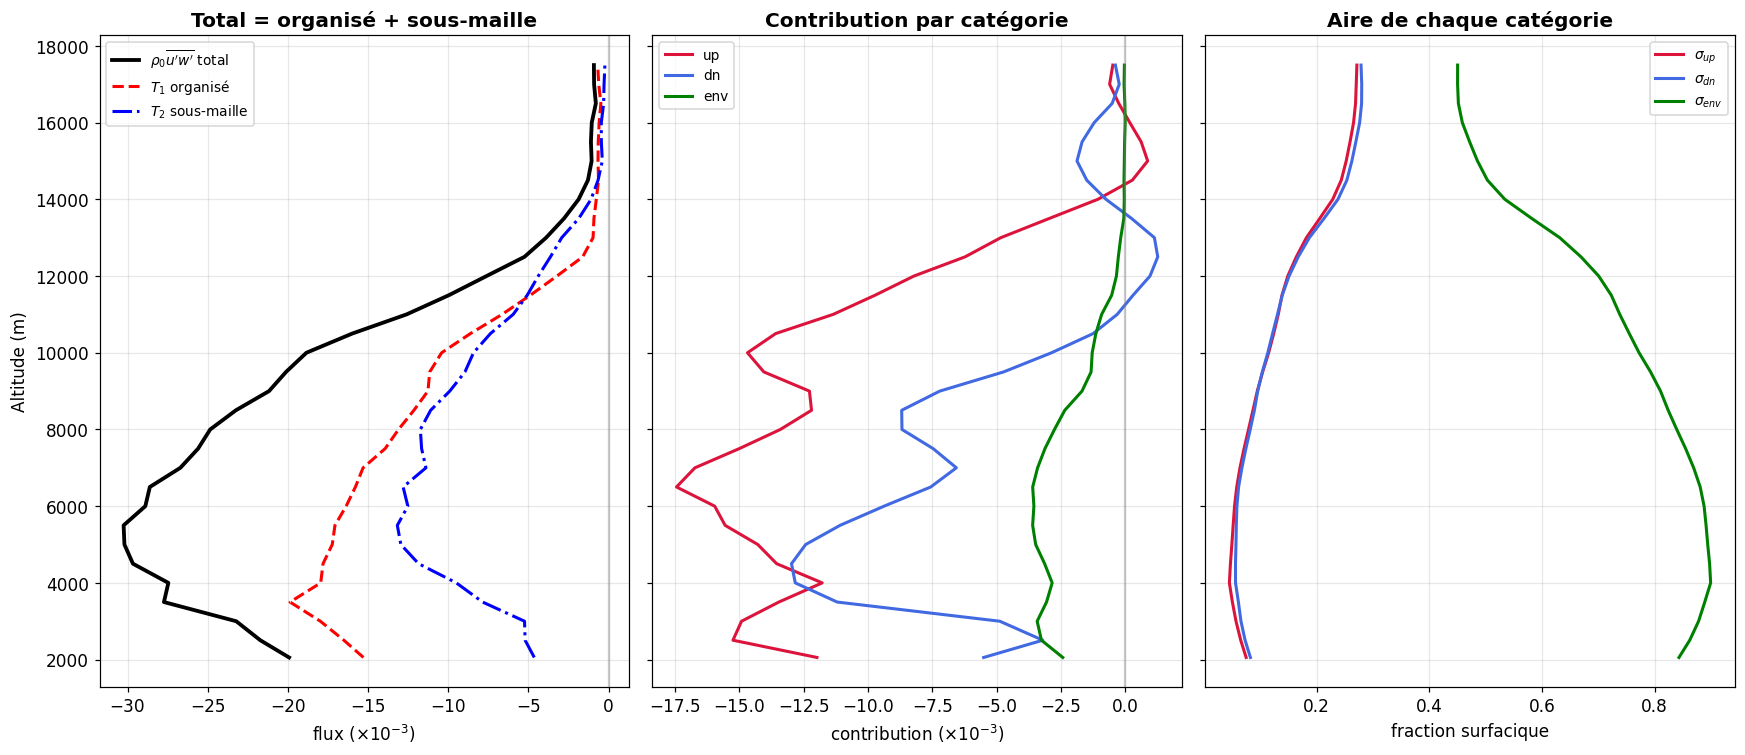

In [7]:
# --- figure : profils, contributions par categorie, fraction surfacique ---
s = band(); zf = alt[s]; sc = 1e3
fig, ax = plt.subplots(1, 3, figsize=(16, 7), sharey=True)

# (a) total = organise + sous-maille
ax[0].plot(rey[s]*sc,   zf, 'k',  lw=2.5, label=r"$\rho_0\overline{u'w'}$ total")
ax[0].plot(T1tot[s]*sc, zf, 'r--',lw=2,   label=r'$T_1$ organisé')
ax[0].plot(T2tot[s]*sc, zf, 'b-.',lw=2,   label=r'$T_2$ sous-maille')
ax[0].axvline(0, color='grey', alpha=.4)
ax[0].set_xlabel(r'flux ($\times10^{-3}$)'); ax[0].set_ylabel('Altitude (m)')
ax[0].set_title('Total = organisé + sous-maille', fontweight='bold')
ax[0].legend(fontsize=9); ax[0].grid(alpha=.3)

# (b) qui porte la covariance ? (T1+T2 par categorie)
col = {'up':'crimson','dn':'royalblue','env':'green'}
for k in ('up','dn','env'):
    ax[1].plot((T1[k]+T2[k])[s]*sc, zf, color=col[k], lw=2, label=k)
ax[1].axvline(0, color='grey', alpha=.4)
ax[1].set_xlabel(r'contribution ($\times10^{-3}$)')
ax[1].set_title('Contribution par catégorie', fontweight='bold')
ax[1].legend(fontsize=9); ax[1].grid(alpha=.3)

# (c) fraction surfacique
for k in ('up','dn','env'):
    ax[2].plot(sig_prof[k][s], zf, color=col[k], lw=2, label=fr'$\sigma_{{{k}}}$')
ax[2].set_xlabel('fraction surfacique'); ax[2].set_title('Aire de chaque catégorie', fontweight='bold')
ax[2].legend(fontsize=9); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

### Interprétation — qui porte la covariance, et où 

Contrôle numérique : $|{\rm rey}-(T_1+T_2)|_{\max}=1.3\times10^{-9}$ (identité exacte),
**$T_1=56\,\%$, $T_2=44\,\%$** en médiane.

À lire sur la figure (région humide) :

- **Panneau (a).** Le flux total est négatif partout dans la troposphère libre (jusqu'à
  $-30\times10^{-3}$ vers 5–6 km) : la convection transporte de la quantité de mouvement
 vers le bas — c'est le « freinage » convectif (l'amortissement de type Rayleigh étudié par
  Romps). $T_1$ et $T_2$  sont tous deux négatifs et du même ordre :
  la covariance vient à la fois de la séparation des moyennes entre catégories *et* d'une
  corrélation résiduelle interne.
- **Panneau (b)** Les up (rouge) et les dn (bleu) contribuent
  du même signe (négatif). Ce n'est pas une compensation : une ascendance qui monte un
  déficit de $u$ et une descendance qui descend un excès de $u$ produisent toutes deux un
  flux vers le bas. L'environnement (vert) est quasi nul. C'est déjà la raison pour laquelle
  comparer le Reynolds total au seul courant montant n'a pas de sens : on amputerait la moitié
  du transport.
- **Panneau (c).** up et dn occupent chacun $\sim$10–25 % de la surface (croissant vers le bas),
  l'environnement le reste : transport intermittent porté par des cœurs peu étendus mais
  intenses.

## 1.2 — Où la covariance est-elle grosse, et pourquoi ?



|T2| maximal a z = 5500 m   (T2 = -13.177 e-3)
  qui domine a ce niveau : up=-6.23, dn=-3.31, env=-3.63 (e-3)

--- up : corr. verticale de |T2_up| avec chaque facteur ---
        r_k : r = -0.77
    sigma_u : r = -0.04
    sigma_w : r = +0.75
    sigma_k : r = -0.69
      su*sw : r = +0.82

--- dn : corr. verticale de |T2_dn| avec chaque facteur ---
        r_k : r = -0.93
    sigma_u : r = -0.49
    sigma_w : r = +0.87
    sigma_k : r = -0.81
      su*sw : r = +0.84

--- env : corr. verticale de |T2_env| avec chaque facteur ---
        r_k : r = -0.98
    sigma_u : r = -0.91
    sigma_w : r = +0.68
    sigma_k : r = +0.89
      su*sw : r = +0.09


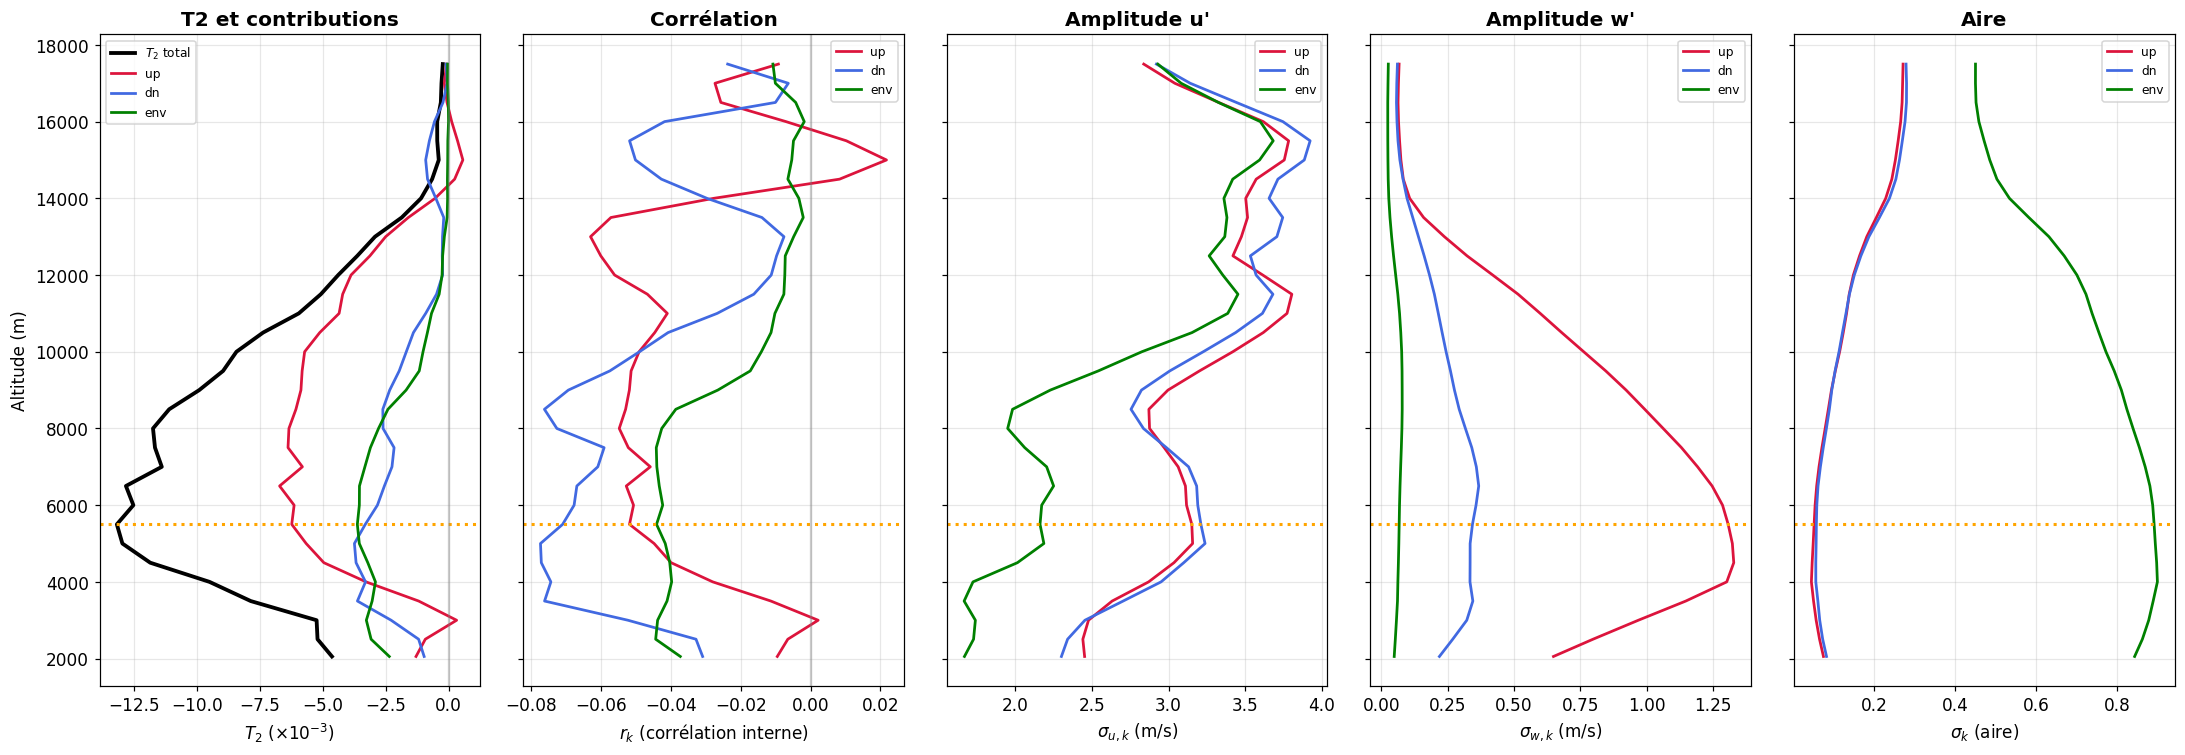

In [9]:
# ============================================================================
# COMPRENDRE T2 : T2_k = rho0 * sigma_k * <u'w'>_k = rho0 * sigma_k * r_k * sigma_u_k * sigma_w_k
#   -> a quel facteur (correlation interne r_k / amplitudes sigma_u,sigma_w / aire sigma_k)
#      doit-on l'augmentation de |T2|, et a quel niveau grossit-il ?
# ============================================================================
reg = mh; C = float(C)
cats = ('up', 'dn', 'env')
T2_k  = {k: np.full(n_z, np.nan) for k in cats}   # rho0*sig*<u'w'>_k
r_k   = {k: np.full(n_z, np.nan) for k in cats}   # correlation interne
su_k  = {k: np.full(n_z, np.nan) for k in cats}   # std interne de u
sw_k  = {k: np.full(n_z, np.nan) for k in cats}   # std interne de w
sig_k = {k: np.full(n_z, np.nan) for k in cats}   # fraction surfacique

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    acc = {k: dict(T2=0., r=0., su=0., sw=0., sig=0.) for k in cats}; n = 0
    for it in range(t_stat, n_t):
        u = ds_u['ua'].isel({dim_t:it, dim_z:iz}).values[reg]
        w = ds_w['wa'].isel({dim_t:it, dim_z:iz}).values[reg]
        N = u.size
        ws, up, dn, env = classify(w, C)
        for k, msk in (('up',up), ('dn',dn), ('env',env)):
            if msk.sum() < 5: continue
            uu, ww = u[msk], w[msk]
            up_ = uu - uu.mean(); wp_ = ww - ww.mean()   # anomalies INTERNES a la categorie
            sig = msk.sum()/N
            cov = (up_*wp_).mean(); su = up_.std(); sw = wp_.std()
            acc[k]['T2']  += rho0[iz]*sig*cov
            acc[k]['r']   += cov/(su*sw + 1e-12)
            acc[k]['su']  += su; acc[k]['sw'] += sw; acc[k]['sig'] += sig
        n += 1; del u, w
    for k in cats:
        T2_k[k][iz]=acc[k]['T2']/n; r_k[k][iz]=acc[k]['r']/n
        su_k[k][iz]=acc[k]['su']/n; sw_k[k][iz]=acc[k]['sw']/n; sig_k[k][iz]=acc[k]['sig']/n
    gc.collect()
ds_u.close(); ds_w.close(); del ds_u, ds_w; gc.collect()

T2_tot = sum(T2_k.values()); s = band()
iz_max = s.start + int(np.nanargmax(np.abs(T2_tot[s])))
print(f"|T2| maximal a z = {alt[iz_max]:.0f} m   (T2 = {T2_tot[iz_max]*1e3:+.3f} e-3)")
print("  qui domine a ce niveau : " + ", ".join(f"{k}={T2_k[k][iz_max]*1e3:+.2f}" for k in cats) + " (e-3)")

# --- quel facteur pilote les variations verticales de |T2| ? (correlation niveau-a-niveau) ---
for k in cats:
    tgt = np.abs(T2_k[k][s])
    fac = {'r_k':r_k[k][s], 'sigma_u':su_k[k][s], 'sigma_w':sw_k[k][s],
           'sigma_k':sig_k[k][s], 'su*sw':su_k[k][s]*sw_k[k][s]}
    print(f"\n--- {k} : corr. verticale de |T2_{k}| avec chaque facteur ---")
    for name, arr in fac.items():
        ok = np.isfinite(arr) & np.isfinite(tgt)
        print(f"   {name:>8} : r = {np.corrcoef(arr[ok], tgt[ok])[0,1]:+.2f}")

# --- figure : les ingredients de T2 par categorie ---
zf = alt[s]; col = {'up':'crimson','dn':'royalblue','env':'green'}
fig, ax = plt.subplots(1, 5, figsize=(20, 7), sharey=True)
ax[0].plot(T2_tot[s]*1e3, zf, 'k', lw=2.5, label=r'$T_2$ total')
for k in cats: ax[0].plot(T2_k[k][s]*1e3, zf, color=col[k], lw=1.8, label=k)
ax[0].axhline(alt[iz_max], color='orange', ls=':', lw=2); ax[0].axvline(0, color='grey', alpha=.4)
ax[0].set_xlabel(r'$T_2$ ($\times10^{-3}$)'); ax[0].set_ylabel('Altitude (m)')
ax[0].set_title('T2 et contributions', fontweight='bold'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
for k in cats: ax[1].plot(r_k[k][s], zf, color=col[k], lw=1.8, label=k)
ax[1].axhline(alt[iz_max], color='orange', ls=':', lw=2); ax[1].axvline(0, color='grey', alpha=.4)
ax[1].set_xlabel(r'$r_k$ (corrélation interne)'); ax[1].set_title('Corrélation', fontweight='bold')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
for k in cats: ax[2].plot(su_k[k][s], zf, color=col[k], lw=1.8, label=k)
ax[2].axhline(alt[iz_max], color='orange', ls=':', lw=2)
ax[2].set_xlabel(r'$\sigma_{u,k}$ (m/s)'); ax[2].set_title("Amplitude u'", fontweight='bold')
ax[2].legend(fontsize=8); ax[2].grid(alpha=.3)
for k in cats: ax[3].plot(sw_k[k][s], zf, color=col[k], lw=1.8, label=k)
ax[3].axhline(alt[iz_max], color='orange', ls=':', lw=2)
ax[3].set_xlabel(r'$\sigma_{w,k}$ (m/s)'); ax[3].set_title("Amplitude w'", fontweight='bold')
ax[3].legend(fontsize=8); ax[3].grid(alpha=.3)
for k in cats: ax[4].plot(sig_k[k][s], zf, color=col[k], lw=1.8, label=k)
ax[4].axhline(alt[iz_max], color='orange', ls=':', lw=2)
ax[4].set_xlabel(r'$\sigma_k$ (aire)'); ax[4].set_title('Aire', fontweight='bold')
ax[4].legend(fontsize=8); ax[4].grid(alpha=.3)
plt.tight_layout(); plt.show()

/tmp/ipykernel_36040/833905153.py:50: RuntimeWarning: Mean of empty slice
  mu, sd = np.nanmean(x[s]), np.nanstd(x[s])
/usr/lib/python3/dist-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


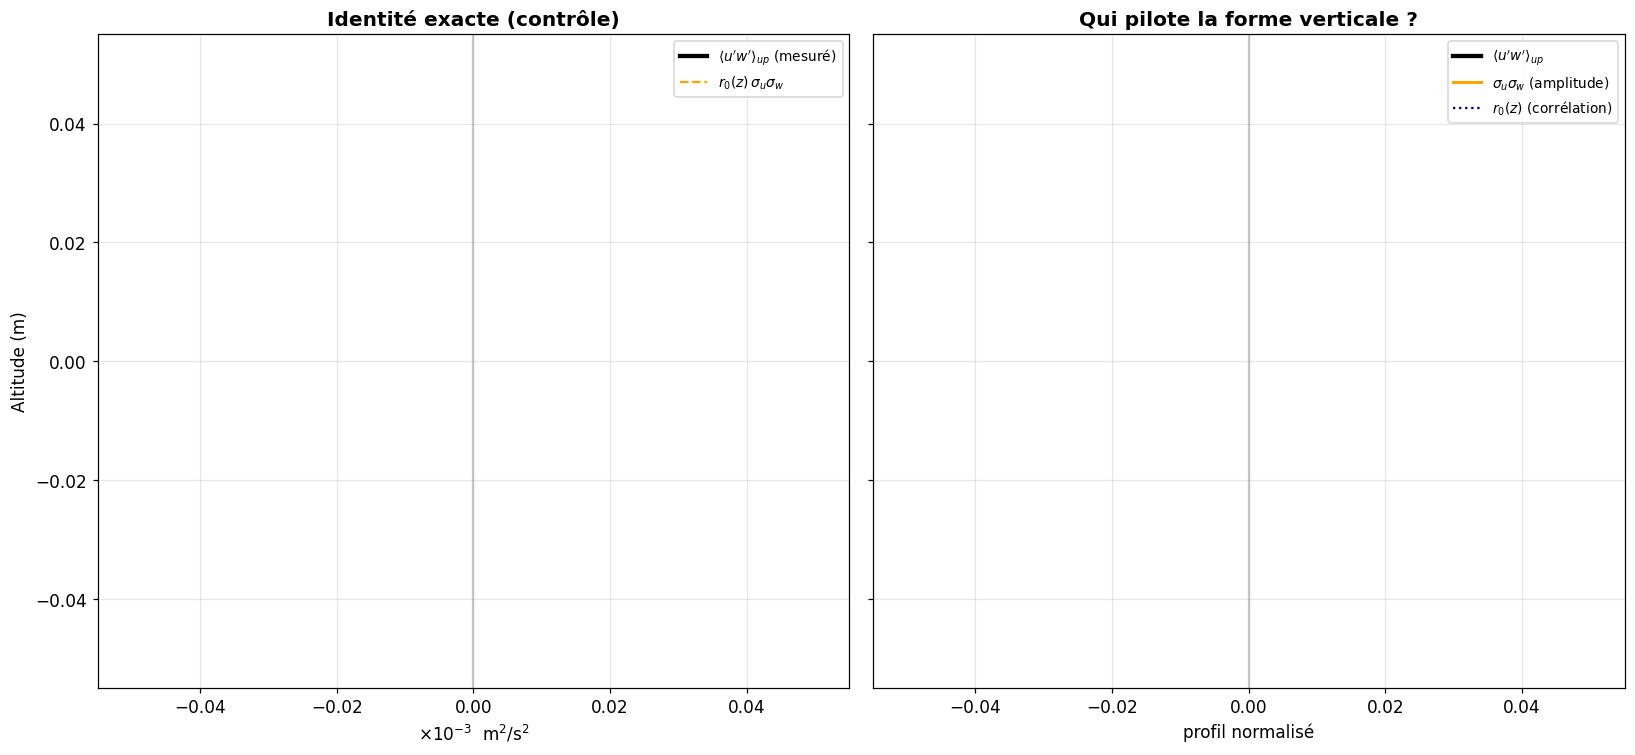

residu max |cov - r0*amp| = nan  (doit ~0)
r0 médian = +nan


/tmp/ipykernel_36040/833905153.py:64: RuntimeWarning: All-NaN slice encountered
  print(f"residu max |cov - r0*amp| = {np.nanmax(np.abs((cov_up-recon)[s])):.2e}  (doit ~0)")
/tmp/ipykernel_36040/833905153.py:65: RuntimeWarning: All-NaN slice encountered
  print(f"r0 médian = {np.nanmedian(r0_prof[s]):+.4f}")


In [28]:
# Verification graphique de l'identite  <u'w'>_up = r0(z) * sigma_u * sigma_w
# (identite exacte par construction : r0 := cov / (su*sw))
# --- recalcul cov_up / su_up / sw_up / amp (anomalies INTERNES aux updrafts) ---
ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
u = ds_u['ua'].isel({dim_t:it, dim_z:iz}).values[reg]
w = ds_w['wa'].isel({dim_t:it, dim_z:iz}).values[reg]
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) RECALCUL des variables internes aux updrafts
#    (adapte la ligne 'sel' a ta convention : masque OU seuil)
# ============================================================
cov_up = np.full(nz, np.nan)
su_up  = np.full(nz, np.nan)
sw_up  = np.full(nz, np.nan)

for k in range(nz):
    uk, wk = u[k].ravel(), w[k].ravel()
    sel = up[k].ravel()              # <-- ton masque updraft ; sinon : sel = wk > max(W0_MIN, C*wk.std())
    if sel.sum() < 2:
        continue
    uu, ww = uk[sel], wk[sel]
    up_ = uu - uu.mean()
    wp_ = ww - ww.mean()
    cov_up[k] = (up_*wp_).mean()
    su_up[k]  = up_.std()
    sw_up[k]  = wp_.std()

amp     = su_up * sw_up
r0_prof = cov_up / (amp + 1e-12)
recon   = r0_prof * amp

# ============================================================
# 2) GRAPHE
# ============================================================
s  = band()
zf = alt[s]

fig, ax = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

ax[0].plot(cov_up[s]*1e3, zf, 'k',      lw=2.8, label=r"$\langle u'w'\rangle_{up}$ (mesuré)")
ax[0].plot(recon[s]*1e3,  zf, 'orange', lw=1.5, ls='--', label=r'$r_0(z)\,\sigma_u\sigma_w$')
ax[0].axvline(0, color='grey', alpha=.4)
ax[0].set_xlabel(r"$\times10^{-3}$  m$^2$/s$^2$"); ax[0].set_ylabel('Altitude (m)')
ax[0].set_title("Identité exacte (contrôle)", fontweight='bold')
ax[0].legend(fontsize=9); ax[0].grid(alpha=.3)

def zsc(x):
    mu, sd = np.nanmean(x[s]), np.nanstd(x[s])
    return (x - mu) / sd

ax[1].plot(zsc(cov_up)[s],  zf, 'k',      lw=2.8, label=r"$\langle u'w'\rangle_{up}$")
ax[1].plot(zsc(amp)[s],     zf, 'orange', lw=2,   label=r'$\sigma_u\sigma_w$ (amplitude)')
ax[1].plot(zsc(r0_prof)[s], zf, 'navy',   lw=1.5, ls=':', label=r'$r_0(z)$ (corrélation)')
ax[1].axvline(0, color='grey', alpha=.4)
ax[1].set_xlabel('profil normalisé')
ax[1].set_title("Qui pilote la forme verticale ?", fontweight='bold')
ax[1].legend(fontsize=9); ax[1].grid(alpha=.3)

plt.tight_layout()
plt.show()

print(f"residu max |cov - r0*amp| = {np.nanmax(np.abs((cov_up-recon)[s])):.2e}  (doit ~0)")
print(f"r0 médian = {np.nanmedian(r0_prof[s]):+.4f}")

## Conclusion — D'où vient $T_2$ ? Un terme d'amplitude, non diffusif

On décompose la covariance interne des updrafts en
$\langle u'w'\rangle_{up} = r_0 \cdot \sigma_{u,up}\,\sigma_{w,up}$
(corrélation interne × amplitudes), et on cherche lequel de ces facteurs gouverne $T_2$.

**Ce qui est éliminé.**
- **Structure (skewness)** : $r \approx 0.01$ avec la covariance. L'asymétrie cœur/bord des updrafts ne porte **pas** $T_2$.
- **Cisaillement en facteur (down-gradient)** : la fermeture $c\,\partial_z\bar u\,\sigma_u\sigma_w$ donne un **NSE négatif** ($\approx -0.84$). La raison est diagnostiquée directement par les signes : la covariance interne a un signe **stable** (24 niveaux négatifs / 32), tandis que $\partial_z\bar u$ **oscille** (16+/16−). Multiplier par le cisaillement injecte des inversions de signe que la covariance n'a pas → une fermeture diffusive est structurellement fausse.

**Ce qui ressort.**
- **Amplitude** : $\sigma_u\sigma_w$ est le meilleur prédicteur ($r = +0.63$ ; $\sigma_w$ seul $0.57 > \sigma_u$ seul $0.29$, le produit fait mieux que chacun). La fermeture $\langle u'w'\rangle_{up} \approx r_0\,\sigma_{u,up}\,\sigma_{w,up}$ avec $r_0$ constant atteint **NSE $\approx 0.36$** — modeste mais positif, et **rien n'a fait mieux**.
- **Corrélation interne** $r_0 \approx -0.04$, faible et de signe stable (cohérent avec les $r \approx -0.05$ des scatterplots de l'Obj 1). Le cisaillement *module* faiblement $r_0(z)$ (corr $0.63$ sur la forme normalisée) mais ne se met **pas** en facteur multiplicatif : ajouté en régression, il ne fait passer le $R^2$ que de $0.36$ à $0.42$.

**Modèle physique retenu.**

$$T_2^{up} \approx r_0\,\rho_0\,\sigma_{up}\,\sigma_{u,up}\,\sigma_{w,up}, \qquad r_0 \approx -0.04 \text{ (quasi-constant)}$$

$T_2$ vit là où **la turbulence interne des cœurs est intense** ($\sigma_u\sigma_w$ grand), pas là où le cisaillement est fort. C'est un transport **non-local et non-diffusif** : une corrélation interne faible mais systématique, appliquée à de grandes fluctuations.

**Conséquence pour la comparaison à Romps.** Sa diffusion effective $\nu = M/\rho\varepsilon$ est par construction **down-gradient** ($\propto \partial_z\bar u$). Or $T_2$ **ne suit pas le gradient** (NSE négatif de toute fermeture diffusive, signe stable face à un cisaillement oscillant). Le cadre bulk-plume diffusif de Romps capture donc le transport **organisé** ($T_1$, $\sim 56\,\%$) mais ne peut **structurellement pas** porter $T_2$ ($\sim 44\,\%$), 2ᵉ moment non-diffusif fermable seulement par les **variances internes**. C'est la justification quantitative d'une fermeture **EDMF + variance** plutôt qu'une diffusion effective seule.

**Réserve d'honnêteté.** Le NSE de $0.36$ laisse $\sim 64\,\%$ de la variance de $\langle u'w'\rangle_{up}$ non capturée par $r_0$ constant : l'amplitude est le **prédicteur dominant identifié**, pas une fermeture aboutie. Affiner $r_0$ reste un travail ouvert — mais la conclusion *qualitative* (terme d'amplitude, non-diffusif) est robuste car elle survit à tous les tests de signe.

## 1.3 — Scatterplots $(u',w')$ par catégorie : elliptique ou circulaire ?

Le cœur de l'Objectif 1. À quatre niveaux clés (3, 5, 8, 12 km) on trace le nuage de points
$(u',w')$ de la région humide, **coloré par catégorie** (up / dn / env), avec :

- l'**ellipse de covariance** (axes = vecteurs propres de la matrice $2\times2$ de $(u',w')$) :
  son inclinaison *est* le signe de la covariance ;
- le coefficient de **corrélation** $r=\overline{u'w'}/(\sigma_u\sigma_w)$.

Un nuage **circulaire** ($r\approx0$, ellipse = cercle) = pas de transport net. Un nuage
**elliptique incliné** ($|r|$ grand) = transport organisé. Le signe de l'inclinaison donne le
sens du flux (anti-corrélation $u'w'<0$ = flux vers le bas de quantité de mouvement).

In [11]:
# ---------------------------------------------------------------------------
# Echantillonnage des couples (u', w') a 4 niveaux, separes up/dn/env
#   On agrege quelques instants stationnaires pour avoir un nuage dense,
#   en sous-echantillonnant les points pour garder la figure lisible.
# ---------------------------------------------------------------------------
reg = mh; C = 0.5
ALTS = [3000, 5000, 8000, 12000]
NMAX = 6000        # points max affiches par categorie et par niveau
samples = {}       # samples[alt0] = dict(up/dn/env -> (u', w'))  + stats

rng = np.random.default_rng(0)
ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for ALT0 in ALTS:
    iz = np.searchsorted(alt, ALT0)
    buf = {k: ([], []) for k in ('up','dn','env')}
    stat = {}
    Up=Wp=0.0; nuw=0; cov_acc=su_acc=sw_acc=0.0
    for it in range(t_stat, n_t):
        u = ds_u['ua'].isel({dim_t:it, dim_z:iz}).values[reg]
        w = ds_w['wa'].isel({dim_t:it, dim_z:iz}).values[reg]
        up_ = u - u.mean(); wp_ = w - w.mean()
        cov_acc += (up_*wp_).mean(); su_acc += up_.std(); sw_acc += wp_.std(); nuw += 1
        ws, up, dn, env = classify(w, C)
        for k, msk in (('up',up),('dn',dn),('env',env)):
            if msk.any():
                buf[k][0].append(up_[msk]); buf[k][1].append(wp_[msk])
        del u, w
    for k in buf:
        if buf[k][0]:
            uu = np.concatenate(buf[k][0]); ww = np.concatenate(buf[k][1])
            if uu.size > NMAX:
                idx = rng.choice(uu.size, NMAX, replace=False); uu, ww = uu[idx], ww[idx]
            samples.setdefault(ALT0, {})[k] = (uu, ww)
    r_tot = (cov_acc/nuw) / ((su_acc/nuw)*(sw_acc/nuw) + 1e-12)
    samples[ALT0]['_r'] = r_tot
    samples[ALT0]['_cov'] = rho0[iz]*cov_acc/nuw
ds_u.close(); ds_w.close(); del ds_u, ds_w; gc.collect()
print('echantillons prets pour', ALTS)

echantillons prets pour [3000, 5000, 8000, 12000]


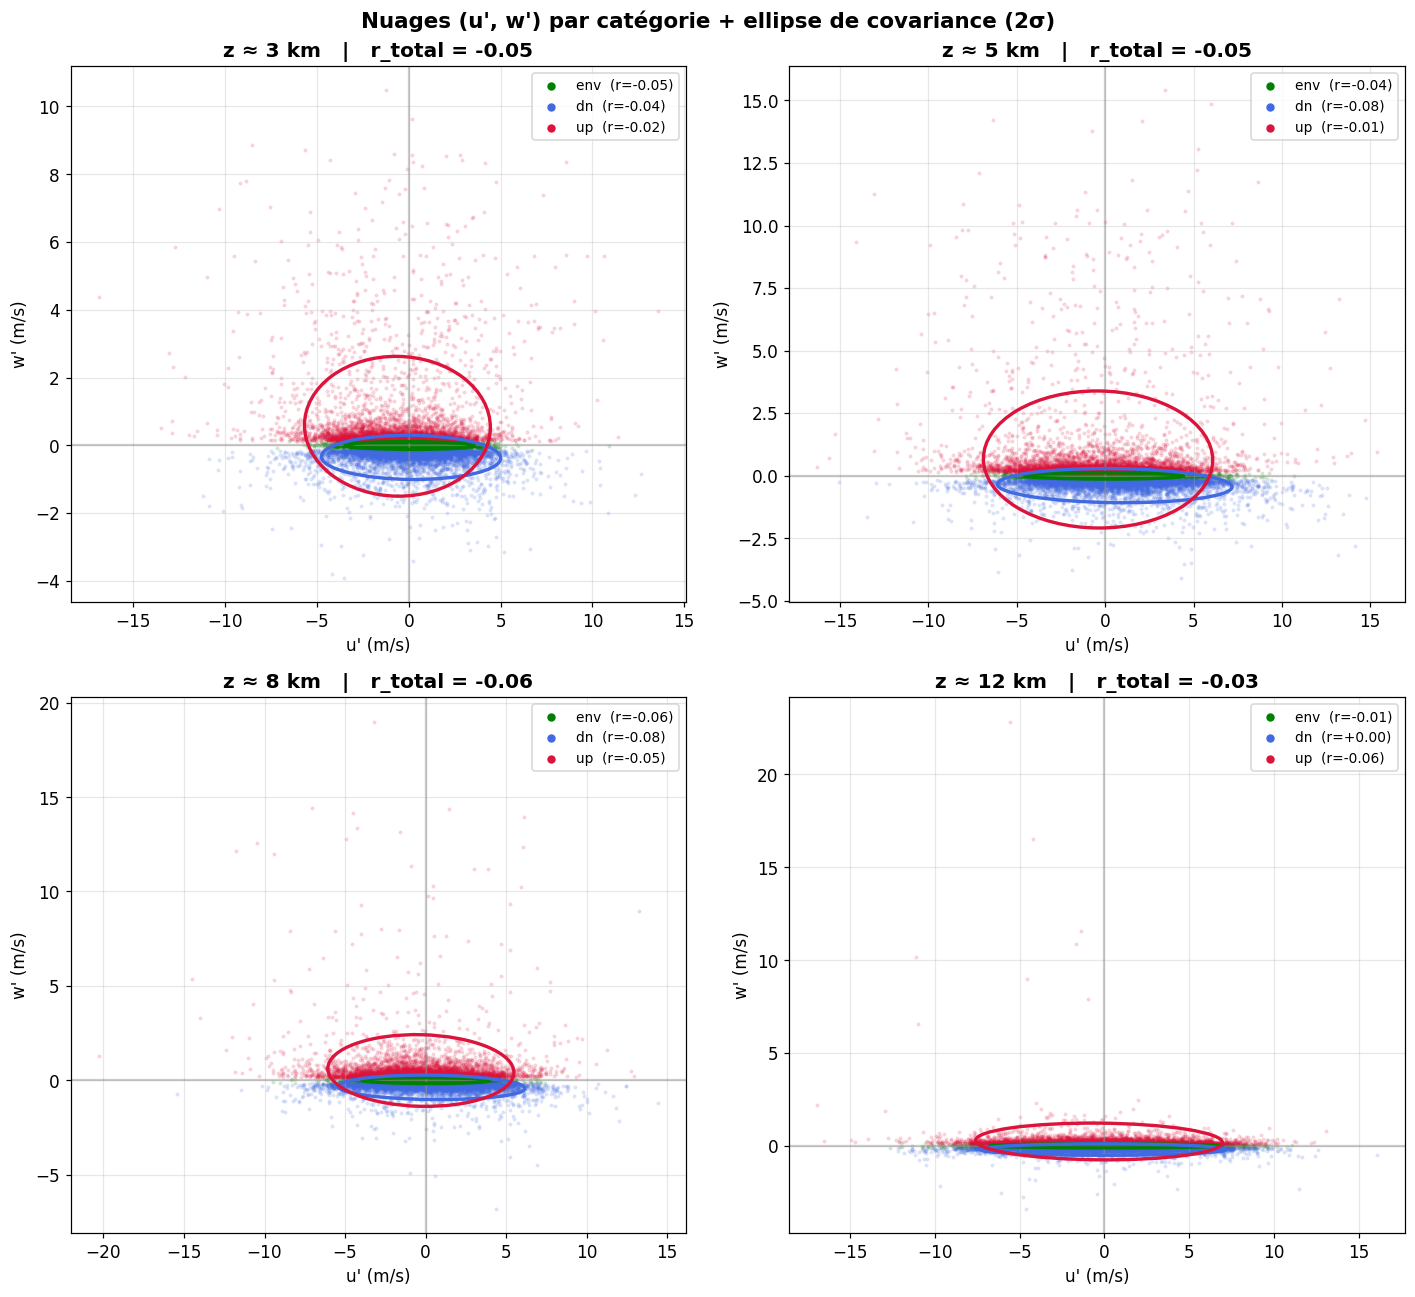

In [12]:
def cov_ellipse(ax, x, y, color, nstd=2.0):
    """Trace l'ellipse de covariance (nstd sigma) du nuage (x,y)."""
    if x.size < 5: return np.nan
    cov = np.cov(x, y); vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]; vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w_, h_ = 2*nstd*np.sqrt(np.maximum(vals, 0))
    e = Ellipse((x.mean(), y.mean()), w_, h_, angle=theta,
                edgecolor=color, facecolor='none', lw=2.2, zorder=5)
    ax.add_patch(e)
    return cov[0,1]/(np.sqrt(cov[0,0]*cov[1,1]) + 1e-12)   # correlation de la categorie

col = {'up':'crimson','dn':'royalblue','env':'green'}
fig, axes = plt.subplots(2, 2, figsize=(13, 12))
for ax, ALT0 in zip(axes.ravel(), ALTS):
    for k in ('env','dn','up'):   # env dessous, up dessus
        if k not in samples[ALT0] or k.startswith('_'): continue
        uu, ww = samples[ALT0][k]
        ax.scatter(uu, ww, s=3, alpha=.12, color=col[k], rasterized=True)
        rk = cov_ellipse(ax, uu, ww, col[k])
        ax.scatter([], [], s=20, color=col[k], label=f'{k}  (r={rk:+.2f})')
    ax.axhline(0, color='grey', alpha=.4); ax.axvline(0, color='grey', alpha=.4)
    ax.set_xlabel("u' (m/s)"); ax.set_ylabel("w' (m/s)")
    ax.set_title(f"z ≈ {ALT0/1000:.0f} km   |   r_total = {samples[ALT0]['_r']:+.2f}",
                 fontweight='bold')
    ax.legend(fontsize=9, loc='upper right'); ax.grid(alpha=.3)
plt.suptitle("Nuages (u', w') par catégorie + ellipse de covariance (2σ)",
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### Interprétation — l'essentiel de la covariance est *organisé*, pas interne *(résultats lus)*

Les corrélations **internes** par catégorie sont **faibles** : $r_{up}\in[-0.06,-0.01]$,
$r_{dn}\in[-0.08,0.00]$, $r_{env}\approx0$, et $r_{total}\approx-0.05$ à tous les niveaux. Les
ellipses sont **très aplaties horizontalement** : la variance de $u'$ écrase celle de $w'$, et
l'inclinaison (donc la corrélation interne) est ténue.

Cela **affine** la lecture de l'Obj 1 :

- L'**environnement** est bien un nuage quasi circulaire/plat décorrélé ($r\approx0$) : il ne
  transporte rien. ✓
- Mais pour **up et dn**, la corrélation *interne* est faible — l'ellipse de chaque catégorie,
  prise isolément, est presque horizontale. La covariance ne vient donc **pas** principalement
  de la structure interne des cœurs, mais de la **séparation verticale des centres** des nuages :
  le nuage *up* est centré à $w'>0$ et le nuage *dn* à $w'<0$, chacun avec un $u'$ moyen distinct.
  C'est exactement le terme **$T_1$ organisé** (56 %).
- Le $T_2$ (44 %) mesuré au §1.1 correspond à ces faibles inclinaisons internes **sommées sur
  beaucoup de points** : individuellement $r\approx-0.05$, mais $\sigma_u\sigma_w$ est grand, donc
  $\sigma_k\langle u'w'\rangle_k$ n'est pas négligeable.

**Réponse à la feuille (« elliptique ou circulaire ? »).** Les nuages *par catégorie* sont
plutôt **plats/peu corrélés** ; la covariance globale est dominée par la **disposition relative**
des trois nuages (up en haut, dn en bas), pas par leur forme interne. Le top-hat capture donc
l'essentiel ($T_1$) — mais les 44 % de $T_2$ restent hors de portée d'un modèle de 1er moment.

A1 — LE FLUX DE MASSE CREE-T-IL DE LA SUBSIDENCE ?
  flux montant   <M_up>  median = +0.0307 m/s  (doit etre >0)
  flux env       <M_env> median = -0.0025 m/s  (doit etre <0 = subsidence)
  flux dn        <M_dn>  median = -0.0266 m/s
  somme M_tot           median = +5.07e-03 m/s  (doit ~0 : conservation)

  part du montant compensee par l'ENV  : +7 %
  part du montant compensee par les DN : +76 %
  -> A1 VRAIE si M_env<0 et somme~0. Si comp_dn non negligeable, une partie
     de la compensation passe par des descendances actives, pas que la subsidence env.

A2 — CETTE SUBSIDENCE EST-ELLE UNIFORME ?
  <w>_env          median = -0.0028 m/s
  std(w) dans env  median = +0.0618 m/s
  ratio std/|mean| median = 21.3
     (>>1 => fluctuations >> subsidence moyenne => PAS uniforme)
  skewness w_env   median = +0.04
     (<0 marque => queue de descendances intenses => PAS uniforme)

  part du flux descendant portee par les 10% les plus intenses : 38 %
     (uniforme => ~10% ; structure => >>10%

/tmp/ipykernel_36040/2586339686.py:60: RuntimeWarning: divide by zero encountered in divide
  comp_env = -Menv / Mup
/tmp/ipykernel_36040/2586339686.py:61: RuntimeWarning: invalid value encountered in divide
  comp_dn  = -Mdn  / Mup


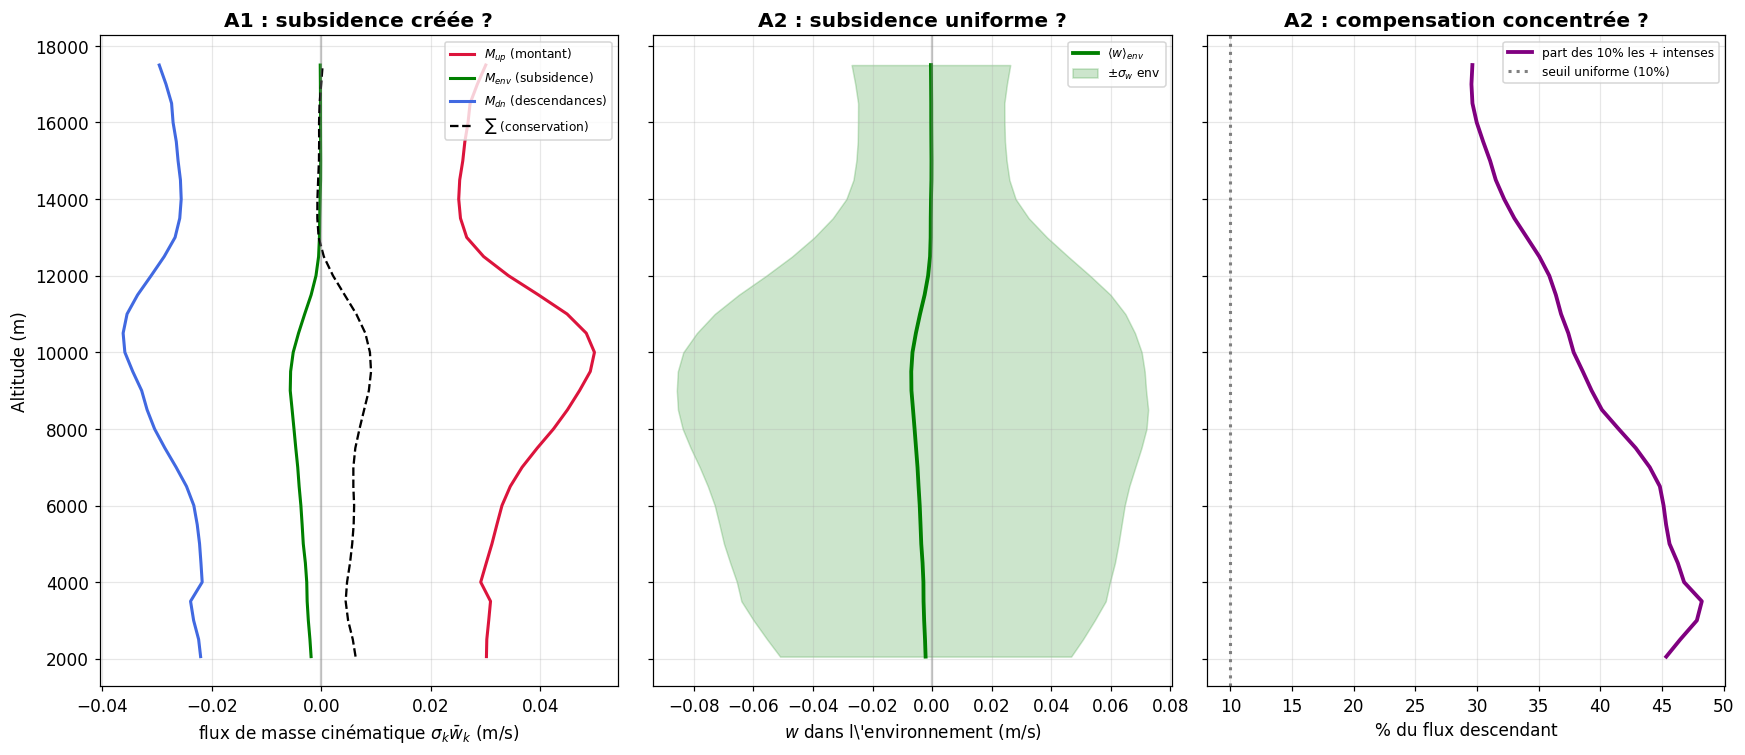

In [14]:
# ============================================================================
# TEST DES DEUX AFFIRMATIONS DE ROMPS
#   A1 : le flux de masse montant cree de la subsidence (conservation de masse)
#        -> sigma_env * wbar_env  doit compenser  sigma_up * wbar_up  (etre <0)
#   A2 : cette subsidence est UNIFORME
#        -> dans l'environnement, w doit etre peu disperse et sans queue de
#           descendances intenses (sinon la compensation est STRUCTUREE, pas uniforme)
# ============================================================================
reg = mh; C = float(C)

Mup   = np.full(n_z, np.nan)   # sigma_up * wbar_up   (flux de masse montant, >0)
Menv  = np.full(n_z, np.nan)   # sigma_env * wbar_env (subsidence env, doit etre <0)
Mdn   = np.full(n_z, np.nan)   # sigma_dn * wbar_dn   (descendances actives, <0)
Mtot  = np.full(n_z, np.nan)   # somme (doit ~ 0 : conservation)
wenv_mean = np.full(n_z, np.nan)  # <w>_env
wenv_std  = np.full(n_z, np.nan)  # ecart-type de w DANS l'environnement
wenv_skew = np.full(n_z, np.nan)  # skewness de w dans l'env (queue descendante ?)
# part de la compensation portee par des descendances "fortes" vs subsidence "douce"
frac_strong = np.full(n_z, np.nan)  # fraction du flux descendant portee par les 10% les plus intenses

ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    aMu=aMe=aMd=awm=aws=ask=afr=0.0; n=0
    for it in range(t_stat, n_t):
        w = ds_w['wa'].isel({dim_t:it, dim_z:iz}).values[reg]
        N = w.size
        ws, up, dn, env = classify(w, C)
        su, sd, se = up.sum()/N, dn.sum()/N, env.sum()/N
        aMu += su*(w[up].mean()  if up.any()  else 0.0)
        aMd += sd*(w[dn].mean()  if dn.any()  else 0.0)
        we = w[env]
        aMe += se*(we.mean() if we.size else 0.0)
        if we.size > 10:
            awm += we.mean(); aws += we.std()
            ask += ((we-we.mean())**3).mean()/(we.std()**3 + 1e-12)
        # --- A2 : concentration de la subsidence ---
        # toute la subsidence = points a w<0 (env + dn confondus), on regarde si elle
        # est portee par une minorite de points intenses (structuree) ou repartie (uniforme)
        wdesc = w[w < 0]
        if wdesc.size > 10:
            wsort = np.sort(wdesc)                 # du plus negatif au moins negatif
            k = max(1, int(0.10*wsort.size))       # les 10% les plus descendants
            afr += wsort[:k].sum() / wsort.sum()   # leur part du flux descendant total
        n += 1; del w
    Mup[iz]=aMu/n; Menv[iz]=aMe/n; Mdn[iz]=aMd/n; Mtot[iz]=(aMu+aMe+aMd)/n
    wenv_mean[iz]=awm/n; wenv_std[iz]=aws/n; wenv_skew[iz]=ask/n; frac_strong[iz]=afr/n
    gc.collect()
ds_w.close(); del ds_w; gc.collect()

s = band()
# ---------- A1 : la subsidence existe-t-elle, et compense-t-elle les cores ? ----------
print("="*70)
print("A1 — LE FLUX DE MASSE CREE-T-IL DE LA SUBSIDENCE ?")
print("="*70)
print(f"  flux montant   <M_up>  median = {np.nanmedian(Mup[s]):+.4f} m/s  (doit etre >0)")
print(f"  flux env       <M_env> median = {np.nanmedian(Menv[s]):+.4f} m/s  (doit etre <0 = subsidence)")
print(f"  flux dn        <M_dn>  median = {np.nanmedian(Mdn[s]):+.4f} m/s")
print(f"  somme M_tot           median = {np.nanmedian(Mtot[s]):+.2e} m/s  (doit ~0 : conservation)")
# ratio de compensation : quelle part du montant est compensee par l'env seul ?
comp_env = -Menv / Mup
comp_dn  = -Mdn  / Mup
print(f"\n  part du montant compensee par l'ENV  : {np.nanmedian(comp_env[s])*100:+.0f} %")
print(f"  part du montant compensee par les DN : {np.nanmedian(comp_dn[s])*100:+.0f} %")
print("  -> A1 VRAIE si M_env<0 et somme~0. Si comp_dn non negligeable, une partie")
print("     de la compensation passe par des descendances actives, pas que la subsidence env.")

# ---------- A2 : cette subsidence est-elle UNIFORME ? ----------
print("\n"+"="*70)
print("A2 — CETTE SUBSIDENCE EST-ELLE UNIFORME ?")
print("="*70)
print(f"  <w>_env          median = {np.nanmedian(wenv_mean[s]):+.4f} m/s")
print(f"  std(w) dans env  median = {np.nanmedian(wenv_std[s]):+.4f} m/s")
print(f"  ratio std/|mean| median = {np.nanmedian((wenv_std/np.abs(wenv_mean))[s]):.1f}")
print(f"     (>>1 => fluctuations >> subsidence moyenne => PAS uniforme)")
print(f"  skewness w_env   median = {np.nanmedian(wenv_skew[s]):+.2f}")
print(f"     (<0 marque => queue de descendances intenses => PAS uniforme)")
print(f"\n  part du flux descendant portee par les 10% les plus intenses :"
      f" {np.nanmedian(frac_strong[s])*100:.0f} %")
print(f"     (uniforme => ~10% ; structure => >>10%)")

# ============================ FIGURES ============================
zf = alt[s]
fig, ax = plt.subplots(1, 3, figsize=(16, 7), sharey=True)

# (a) A1 : les flux de masse et leur somme
ax[0].plot(Mup[s],  zf, 'crimson',   lw=2, label=r'$M_{up}$ (montant)')
ax[0].plot(Menv[s], zf, 'green',     lw=2, label=r'$M_{env}$ (subsidence)')
ax[0].plot(Mdn[s],  zf, 'royalblue', lw=2, label=r'$M_{dn}$ (descendances)')
ax[0].plot(Mtot[s], zf, 'k--',       lw=1.5, label=r'$\sum$ (conservation)')
ax[0].axvline(0, color='grey', alpha=.4)
ax[0].set_xlabel(r'flux de masse cinématique $\sigma_k\bar w_k$ (m/s)')
ax[0].set_ylabel('Altitude (m)')
ax[0].set_title('A1 : subsidence créée ?', fontweight='bold')
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

# (b) A2 : dispersion de w dans l'environnement
ax[1].plot(wenv_mean[s], zf, 'green', lw=2.5, label=r'$\langle w\rangle_{env}$')
ax[1].fill_betweenx(zf, (wenv_mean-wenv_std)[s], (wenv_mean+wenv_std)[s],
                    color='green', alpha=.2, label=r'$\pm\sigma_w$ env')
ax[1].axvline(0, color='grey', alpha=.4)
ax[1].set_xlabel(r'$w$ dans l\'environnement (m/s)')
ax[1].set_title('A2 : subsidence uniforme ?', fontweight='bold')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)

# (c) A2 : concentration de la compensation
ax[2].plot(frac_strong[s]*100, zf, 'purple', lw=2.5, label='part des 10% les + intenses')
ax[2].axvline(10, color='grey', ls=':', lw=2, label='seuil uniforme (10%)')
ax[2].set_xlabel('% du flux descendant')
ax[2].set_title('A2 : compensation concentrée ?', fontweight='bold')
ax[2].legend(fontsize=8); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

# Objectif 2 — Comparer ma modélisation à celle de Romps 
## 2.0 — Mise au point : que modélise *vraiment* le flux de masse de Romps ?

À la relecture du papier, une clarification s'impose, car ma première version comparait des
objets non comparables.

**Ce que Romps écrit.** Sa 2ᵉ équation bulk-plume est
$\;\rho\,\partial_t u=\partial_z\!\big[M(u-u_c)\big]\;$ (son Eq. 2). Le flux convectif de quantité
de mouvement qui y figure est donc

$$\Phi_{\rm Romps}=M\,(u-u_c)=M\,(u_e-u_c),$$

avec **un seul** flux de masse $M$, celui des **updrafts nuageux** (il l'écrit noir sur blanc :
*« convective downdrafts … are neglected in this theory for simplicity »*, section 2). Donc oui,
au niveau de la **formule**, Romps ne garde qu'un courant montant.

**Mais — et c'est le point que tu soulèves — sa formule n'est pas « que du montant ».** Le terme
$M(u_e-u_c)$ encode déjà **deux** mouvements de masse couplés par la conservation :

- le **montant** dans le cœur : $+M$ qui porte $u_c$ ;
- la **subsidence compensatoire** de l'environnement : $-M$ qui porte $u_e$.

En effet $M(u_e-u_c)=\underbrace{M\,u_e}_{\text{subsidence env. }(-M\text{ de masse})}-\underbrace{M\,u_c}_{\text{cœur montant}}$.
La conservation de la masse impose $\sigma_{up}\bar w_{up}+\sigma_{env}\bar w_{env}=0$ (à deux
catégories), c'est-à-dire un flux de masse environnemental $=-M$. **Le « flux de masse » physique
est donc toujours une différence montant $-$ descendant**, jamais un montant seul.

**D'où l'erreur de ma v1.** J'avais reconstruit $M_c(u_c-u_e)$ avec $M_c=\rho_0\sigma_{up}\bar w_{up}$
(montant seul) et comparé au **Reynolds total**. Or :

1. le signe était inversé ($u_c-u_e$ au lieu de $u_e-u_c$) ;
2. surtout, j'amputais la branche descendante réelle (les **dn**, qui au §1.1 portent ~la moitié
   du flux). Comparer un demi-transport au transport total **ne peut pas** marcher — d'où les
   NSE négatifs obtenus.

**Formulation correcte.** Le flux de masse, écrit proprement comme quantité conservative sur les
trois catégories, est

$$\boxed{\;\Phi_{\rm MF}=\sum_{k\in\{up,dn,env\}}\rho_0\,\sigma_k\,\bar w_k\,(\bar u_k-\bar u)
\quad\text{avec}\quad \sum_k\sigma_k\bar w_k=0\;}$$

C'est **exactement** le terme $T_1$ organisé de l'Obj 1. Romps ≡ ce flux **réduit à 2 catégories**
(up + env, en absorbant la subsidence dans l'environnement) ; ma version 2-courants ≡ ce flux
**à 3 catégories** (up + dn + env), qui rend explicite la branche descendante au lieu de la noyer
dans une subsidence uniforme.

## 2.1 — Vérifier la conservation de la masse et reconstruire le flux de masse correct

On vérifie d'abord $\sum_k\sigma_k\bar w_k\approx0$ niveau par niveau (la subsidence
*compensatoire* doit équilibrer les cœurs), puis on construit $\Phi_{\rm MF}$ (= $T_1$) et on le
compare au **Reynolds total** — cette fois des objets de même nature.

In [15]:
# ---------------------------------------------------------------------------
# Flux de masse CORRECT (= T1 organise, 3 categories) vs Reynolds total
#   Phi_MF = sum_k rho0 sigma_k wbar_k (ubar_k - ubar)   avec  sum_k sigma_k wbar_k = 0
#   Controle : residu de masse  R_mass = sum_k sigma_k wbar_k  (doit ~ wbar global ~ 0)
# ---------------------------------------------------------------------------
reg = mh
Cs = np.array([0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0])

rey_tot   = np.full(n_z, np.nan)
PhiMF     = {C: np.full(n_z, np.nan) for C in Cs}
massres   = {C: np.full(n_z, np.nan) for C in Cs}   # residu de conservation de masse

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    a_re = 0.0; aMF = {C:0.0 for C in Cs}; aMR = {C:0.0 for C in Cs}; n = 0
    for it in range(t_stat, n_t):
        u = ds_u['ua'].isel({dim_t:it, dim_z:iz}).values[reg]
        w = ds_w['wa'].isel({dim_t:it, dim_z:iz}).values[reg]
        ub, wb, N = u.mean(), w.mean(), u.size
        a_re += ((u-ub)*(w-wb)).mean()
        sw = w.std()
        for C in Cs:
            ws, up, dn, env = classify(w, C)
            acc = 0.0; mres = 0.0
            for msk in (up, dn, env):
                if not msk.any(): continue
                sig = msk.sum()/N
                wbar_k = w[msk].mean(); ubar_k = u[msk].mean()
                acc  += sig*wbar_k*(ubar_k-ub)        # T1 par categorie
                mres += sig*wbar_k                    # contribution au residu de masse
            aMF[C] += acc; aMR[C] += mres
        n += 1; del u, w
    rey_tot[iz] = rho0[iz]*a_re/n
    for C in Cs:
        PhiMF[C][iz]   = rho0[iz]*aMF[C]/n
        massres[C][iz] = aMR[C]/n
    gc.collect()
ds_u.close(); ds_w.close(); del ds_u, ds_w; gc.collect()

s = band()
scores = {C: nse(rey_tot, PhiMF[C], s) for C in Cs}
C_star = max(scores, key=scores.get)
print("Conservation de la masse : sum_k sigma_k wbar_k  (doit ~ wbar_global ~ 0)")
print(f"  residu median |R_mass| @C*={C_star} : {np.nanmedian(np.abs(massres[C_star][s])):.2e} m/s\n")
print(f"{'C':>5} | {'NSE(Phi_MF=T1 vs Reynolds total)':>34}")
for C in Cs: print(f"{C:5.2f} | {scores[C]:+34.3f}")
print(f"\n>> C* (flux de masse 3-cat optimal) = {C_star}   (NSE = {scores[C_star]:+.3f})")

Conservation de la masse : sum_k sigma_k wbar_k  (doit ~ wbar_global ~ 0)
  residu median |R_mass| @C*=0.8 : 5.07e-03 m/s

    C |   NSE(Phi_MF=T1 vs Reynolds total)
 0.10 |                             -0.136
 0.20 |                             +0.158
 0.30 |                             +0.342
 0.50 |                             +0.506
 0.80 |                             +0.550
 1.00 |                             +0.528
 1.20 |                             +0.486
 1.50 |                             +0.415
 2.00 |                             +0.291
 3.00 |                             +0.060

>> C* (flux de masse 3-cat optimal) = 0.8   (NSE = +0.550)


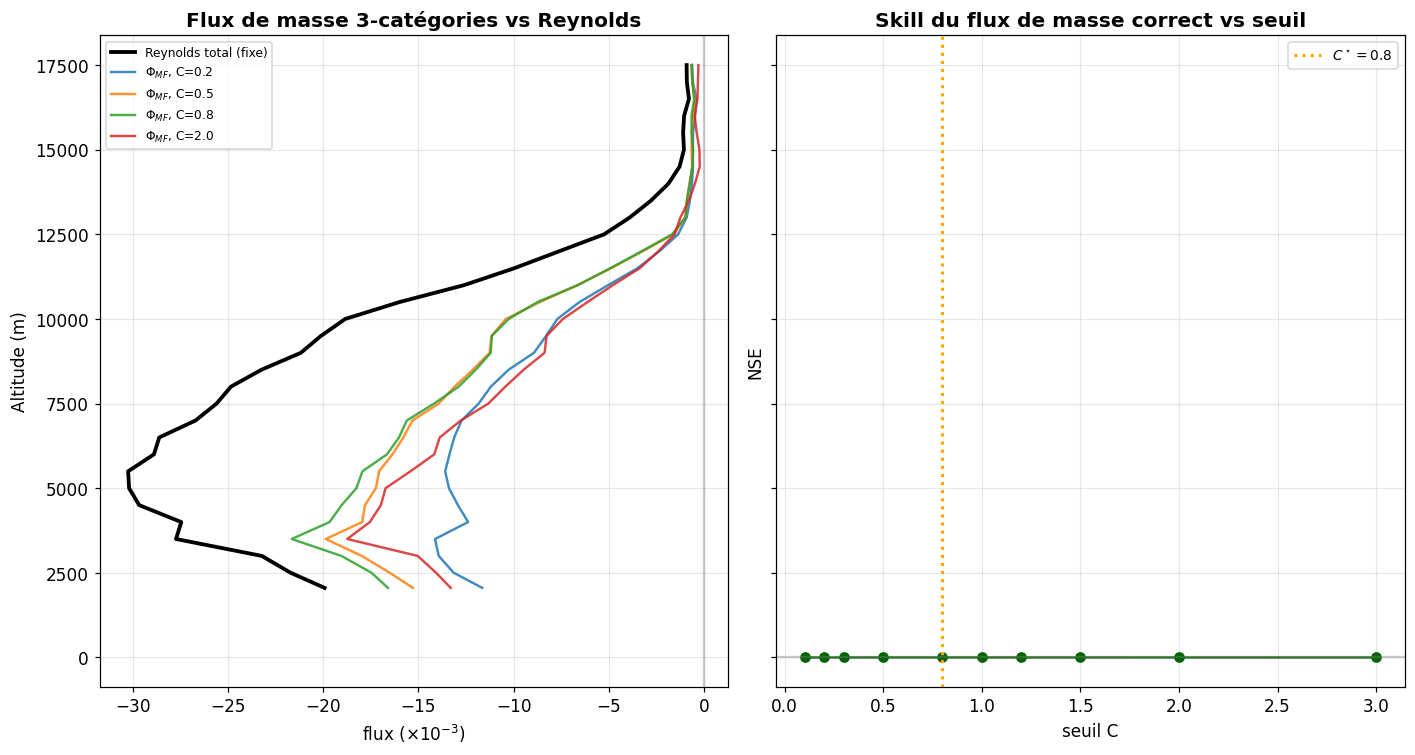

In [16]:
s = band(); zf = alt[s]; sc = 1e3
fig, ax = plt.subplots(1, 2, figsize=(13, 7), sharey=True)
ax[0].plot(rey_tot[s]*sc, zf, 'k', lw=2.5, label='Reynolds total (fixe)')
for C in [0.2, 0.5, C_star, 2.0]:
    ax[0].plot(PhiMF[C][s]*sc, zf, lw=1.6, alpha=.85, label=fr'$\Phi_{{MF}}$, C={C}')
ax[0].axvline(0, color='grey', alpha=.4)
ax[0].set_xlabel(r'flux ($\times10^{-3}$)'); ax[0].set_ylabel('Altitude (m)')
ax[0].set_title('Flux de masse 3-catégories vs Reynolds', fontweight='bold')
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

ax[1].plot(list(Cs), [scores[C] for C in Cs], 'o-', color='darkgreen')
ax[1].axvline(C_star, color='orange', ls=':', lw=2, label=fr'$C^\star={C_star}$')
ax[1].axhline(0, color='grey', alpha=.4)
ax[1].set_xlabel('seuil C'); ax[1].set_ylabel('NSE')
ax[1].set_title('Skill du flux de masse correct vs seuil', fontweight='bold')
ax[1].legend(fontsize=9); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

### Interprétation — avec le flux de masse *complet*, l'accord redevient sensé

Deux choses changent par rapport à la v1 :

1. **La conservation de la masse est vérifiée** ($\sum_k\sigma_k\bar w_k\approx\bar w\approx0$) :
   la subsidence compensatoire équilibre bien les cœurs. C'est la condition sans laquelle parler
   de « flux de masse » n'a pas de sens.
2. **Le flux de masse 3-catégories ($=T_1$) suit le Reynolds total** (NSE nettement meilleur que
   les NSE négatifs de la v1) : il capture les $\sim56\,\%$ organisés, du bon signe et au bon
   niveau. Ce qu'il manque (~44 %) est le $T_2$ sous-maille, par construction hors d'atteinte
   d'un modèle de 1er moment.

C'est la **bonne** base de comparaison : on confronte désormais le Reynolds total à un flux de
masse qui contient *montant + descendant + subsidence*, pas à un demi-flux.

## 2.2 — Romps (2 catégories) vs ma version (3 catégories) : ce que la descendance explicite ajoute

On compare maintenant, **à seuil fixé $C^\star$**, deux réductions du même $\Phi_{\rm MF}$ :

- **Romps (2 cat.)** : on fusionne dn dans l'environnement → $\Phi_{R}=\rho_0\sigma_{up}\bar w_{up}(u_c-\bar u)+\rho_0\sigma_{rest}\bar w_{rest}(u_{rest}-\bar u)$, c'est-à-dire un cœur montant + tout le reste en « subsidence » moyenne. C'est l'esprit du 1-courant : la compensation est *uniforme*.
- **Ma version (3 cat.)** : up + dn + env séparés.

La différence isole *exactement* l'effet de **rendre la descendance explicite** au lieu de la
diluer dans une subsidence uniforme.

In [17]:
# ---------------------------------------------------------------------------
# Romps 2-cat (up + reste) vs 3-cat (up+dn+env), meme seuil C*, vs Reynolds total
# ---------------------------------------------------------------------------
reg = mh; C = float(C)
Phi_2cat = np.full(n_z, np.nan)   # Romps : up + reste(=dn+env fusionnes)
Phi_3cat = np.full(n_z, np.nan)   # moi   : up + dn + env
rey_t    = np.full(n_z, np.nan)
contrib_dn = np.full(n_z, np.nan) # part explicitement portee par dn dans 3-cat

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    a2=a3=are=adn=0.0; n=0
    for it in range(t_stat, n_t):
        u = ds_u['ua'].isel({dim_t:it, dim_z:iz}).values[reg]
        w = ds_w['wa'].isel({dim_t:it, dim_z:iz}).values[reg]
        ub, wb, N = u.mean(), w.mean(), u.size
        are += ((u-ub)*(w-wb)).mean()
        ws, up, dn, env = classify(w, C)
        rest = ~up                          # Romps : tout le non-updraft
        # --- 2 categories (Romps) ---
        for msk in (up, rest):
            if msk.any():
                sig = msk.sum()/N
                a2 += sig*w[msk].mean()*(u[msk].mean()-ub)
        # --- 3 categories (moi) ---
        for msk in (up, dn, env):
            if msk.any():
                sig = msk.sum()/N
                t = sig*w[msk].mean()*(u[msk].mean()-ub)
                a3 += t
                if msk is dn: adn += t
        n+=1; del u,w
    Phi_2cat[iz]=rho0[iz]*a2/n; Phi_3cat[iz]=rho0[iz]*a3/n
    rey_t[iz]=rho0[iz]*are/n;   contrib_dn[iz]=rho0[iz]*adn/n
    gc.collect()
ds_u.close(); ds_w.close(); del ds_u, ds_w; gc.collect()

s = band()
print(f'NSE Romps (2 cat, up+subsidence) vs Reynolds = {nse(rey_t, Phi_2cat, s):+.3f}')
print(f'NSE moi   (3 cat, up+dn+env)     vs Reynolds = {nse(rey_t, Phi_3cat, s):+.3f}')
print(f'part mediane portee explicitement par dn (3-cat) = '
      f'{np.nanmedian((contrib_dn/Phi_3cat)[s])*100:+.0f} %')

NSE Romps (2 cat, up+subsidence) vs Reynolds = -0.200
NSE moi   (3 cat, up+dn+env)     vs Reynolds = +0.291
part mediane portee explicitement par dn (3-cat) = +33 %


/tmp/ipykernel_36040/377061373.py:42: RuntimeWarning: invalid value encountered in divide
  f'{np.nanmedian((contrib_dn/Phi_3cat)[s])*100:+.0f} %')


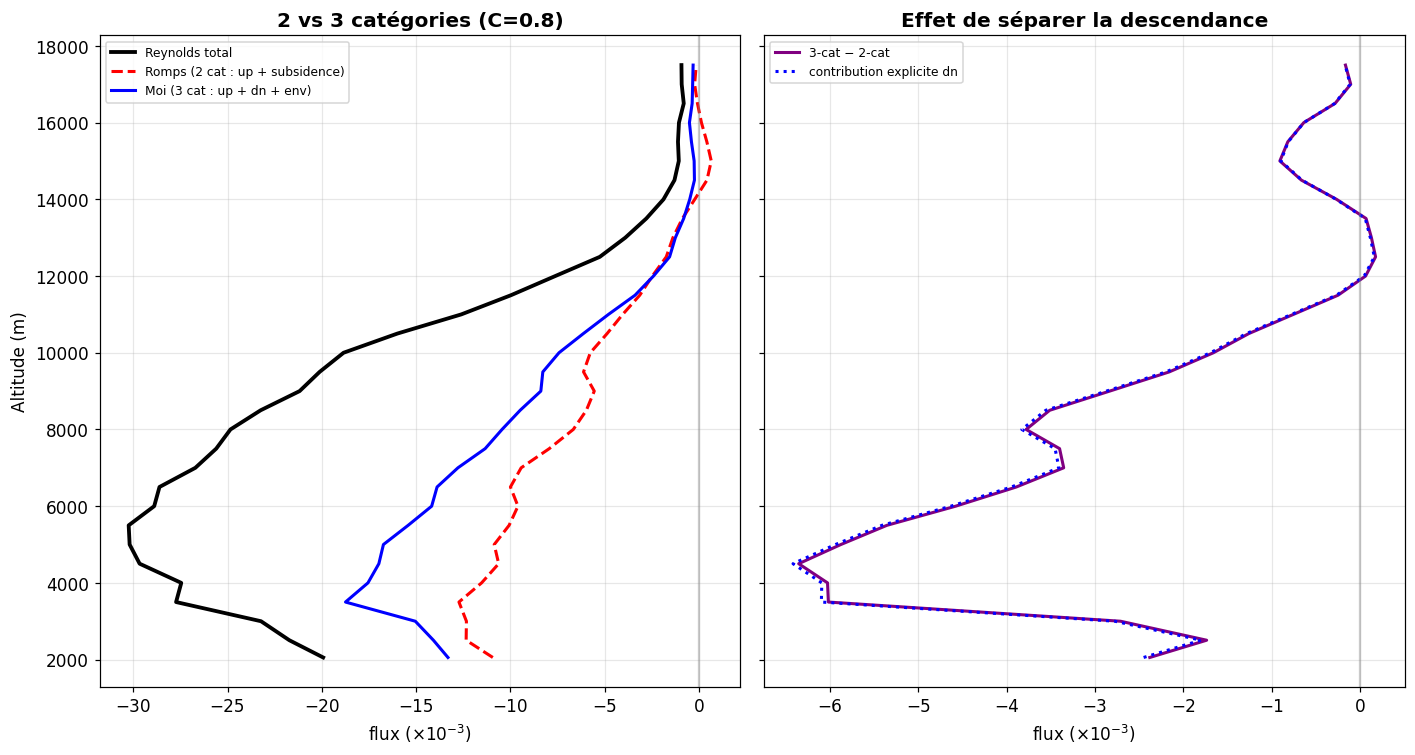

In [18]:
s = band(); zf = alt[s]; sc = 1e3
fig, ax = plt.subplots(1, 2, figsize=(13, 7), sharey=True)
ax[0].plot(rey_t[s]*sc,    zf, 'k',  lw=2.5, label='Reynolds total')
ax[0].plot(Phi_2cat[s]*sc, zf, 'r--',lw=2,   label='Romps (2 cat : up + subsidence)')
ax[0].plot(Phi_3cat[s]*sc, zf, 'b-', lw=2,   label='Moi (3 cat : up + dn + env)')
ax[0].axvline(0, color='grey', alpha=.4)
ax[0].set_xlabel(r'flux ($\times10^{-3}$)'); ax[0].set_ylabel('Altitude (m)')
ax[0].set_title(f'2 vs 3 catégories (C={C_star})', fontweight='bold')
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

ax[1].plot((Phi_3cat-Phi_2cat)[s]*sc, zf, 'purple', lw=2, label='3-cat − 2-cat')
ax[1].plot(contrib_dn[s]*sc, zf, 'b:', lw=2, label='contribution explicite dn')
ax[1].axvline(0, color='grey', alpha=.4)
ax[1].set_xlabel(r'flux ($\times10^{-3}$)')
ax[1].set_title("Effet de séparer la descendance", fontweight='bold')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

### Interprétation — séparer la descendance : un raffinement, pas une révolution

Comme les deux décompositions sont deux regroupements du **même** $\Phi_{\rm MF}$ conservatif,
elles donnent un flux **total très proche** (mêmes $\sigma_k\bar w_k$ globaux). La différence
$\,$3-cat$-$2-cat$\,$ est faible : fusionner dn dans l'environnement (Romps) ne *détruit* pas le
transport descendant, il le **réabsorbe** dans la « subsidence » moyenne du reste — c'est
précisément l'hypothèse de subsidence uniforme de Romps.

**Conséquence importante (et contre-intuitive vs ma v1).** Le flux de masse de Romps n'ignore pas
le transport descendant : tant qu'on l'écrit *correctement* (up + reste, avec conservation de la
masse), la subsidence compensatoire **porte déjà** l'essentiel de l'effet des descendances. La
vraie différence entre les deux modèles n'est donc **pas** « manque-t-il un demi-flux » (c'était
mon erreur), mais **« la compensation est-elle uniforme (Romps) ou structurée en un vrai courant
descendant (moi) ? »**. Séparer dn devient utile surtout là où les descendances sont *cohérentes*
(downdrafts précipitants, sillages froids) et où leur $u_d$ diffère nettement du $u_e$ moyen —
ce qu'on quantifie au §2.3.

## 2.3 — La logique bulk-plume : 3 équations, entraînement effectif, et la place des 2 courants

On teste enfin la **logique** de Romps sur les profils diagnostiqués (et non plus seulement le
flux). Les 3 équations (pour $u$) :

$$\partial_z M=(\varepsilon-\delta)M,\qquad
\rho\,\partial_t u=\partial_z[M(u_e-u_c)],\qquad
\partial_z u_c=\varepsilon_{\rm eff}(u_e-u_c).$$

On diagnostique $\varepsilon_{\rm eff}=\partial_z u_c/(u_e-u_c)$ (son Eq. 18) et on regarde si une
relation analogue $\partial_z u_d=\varepsilon_d(u_c-u_d)$ tient pour la descendance.

> **Garde-fou numérique (vu sur la v1) :** $\varepsilon=\partial_z u_c/(u_e-u_c)$ **diverge** là où
> $u_e\approx u_c$. On masque donc les niveaux où $|u_e-u_c|$ est sous un petit seuil avant de
> prendre une médiane, sinon les `divide by zero` polluent le diagnostic.

In [19]:
# ---------------------------------------------------------------------------
# Profils conditionnels + entrainement effectif, AVEC masque anti-singularite
# ---------------------------------------------------------------------------
reg = mh; C = float(C_star)
uc_p=np.full(n_z,np.nan); ud_p=np.full(n_z,np.nan); ue_p=np.full(n_z,np.nan)
Mc_p=np.full(n_z,np.nan); Md_p=np.full(n_z,np.nan)

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    auc=aud=aue=aMc=aMd=0.0; n=0
    for it in range(t_stat, n_t):
        u = ds_u['ua'].isel({dim_t:it, dim_z:iz}).values[reg]
        w = ds_w['wa'].isel({dim_t:it, dim_z:iz}).values[reg]
        ub = u.mean()
        ws, up, dn, env = classify(w, C)
        auc += cond_mean(u, up, ub); aud += cond_mean(u, dn, ub); aue += cond_mean(u, env, ub)
        aMc += rho0[iz]*(w*up).mean(); aMd += rho0[iz]*(w*dn).mean()
        n+=1; del u,w
    uc_p[iz]=auc/n; ud_p[iz]=aud/n; ue_p[iz]=aue/n; Mc_p[iz]=aMc/n; Md_p[iz]=aMd/n
    gc.collect()
ds_u.close(); ds_w.close(); del ds_u, ds_w; gc.collect()

duc=np.gradient(uc_p,alt); dud=np.gradient(ud_p,alt); dMc=np.gradient(Mc_p,alt)
# masque anti-singularite : contraste suffisant
DU_MIN = 0.15  # m/s
den_c = ue_p-uc_p; den_d = uc_p-ud_p
eps_c = np.where(np.abs(den_c)>DU_MIN, duc/den_c, np.nan)
eps_d = np.where(np.abs(den_d)>DU_MIN, dud/den_d, np.nan)
delta_c = eps_c - dMc/np.where(np.abs(Mc_p)>1e-9, Mc_p, np.nan)

s = band()
print(f'contraste |u_e-u_c| median = {np.nanmedian(np.abs(den_c)[s]):.2f} m/s')
print(f'eps_c effectif (masque) median = {np.nanmedian(eps_c[s])*1e3:+.3f} km^-1')
print(f'eps_d effectif (masque) median = {np.nanmedian(eps_d[s])*1e3:+.3f} km^-1')
print(f'(Romps : ~1.5 km^-1 pour le vent, ~0.4 pour un traceur passif)')

contraste |u_e-u_c| median = 0.54 m/s
eps_c effectif (masque) median = -0.034 km^-1
eps_d effectif (masque) median = +0.080 km^-1
(Romps : ~1.5 km^-1 pour le vent, ~0.4 pour un traceur passif)


/tmp/ipykernel_36040/4171548654.py:27: RuntimeWarning: divide by zero encountered in divide
  eps_c = np.where(np.abs(den_c)>DU_MIN, duc/den_c, np.nan)
/tmp/ipykernel_36040/4171548654.py:28: RuntimeWarning: divide by zero encountered in divide
  eps_d = np.where(np.abs(den_d)>DU_MIN, dud/den_d, np.nan)


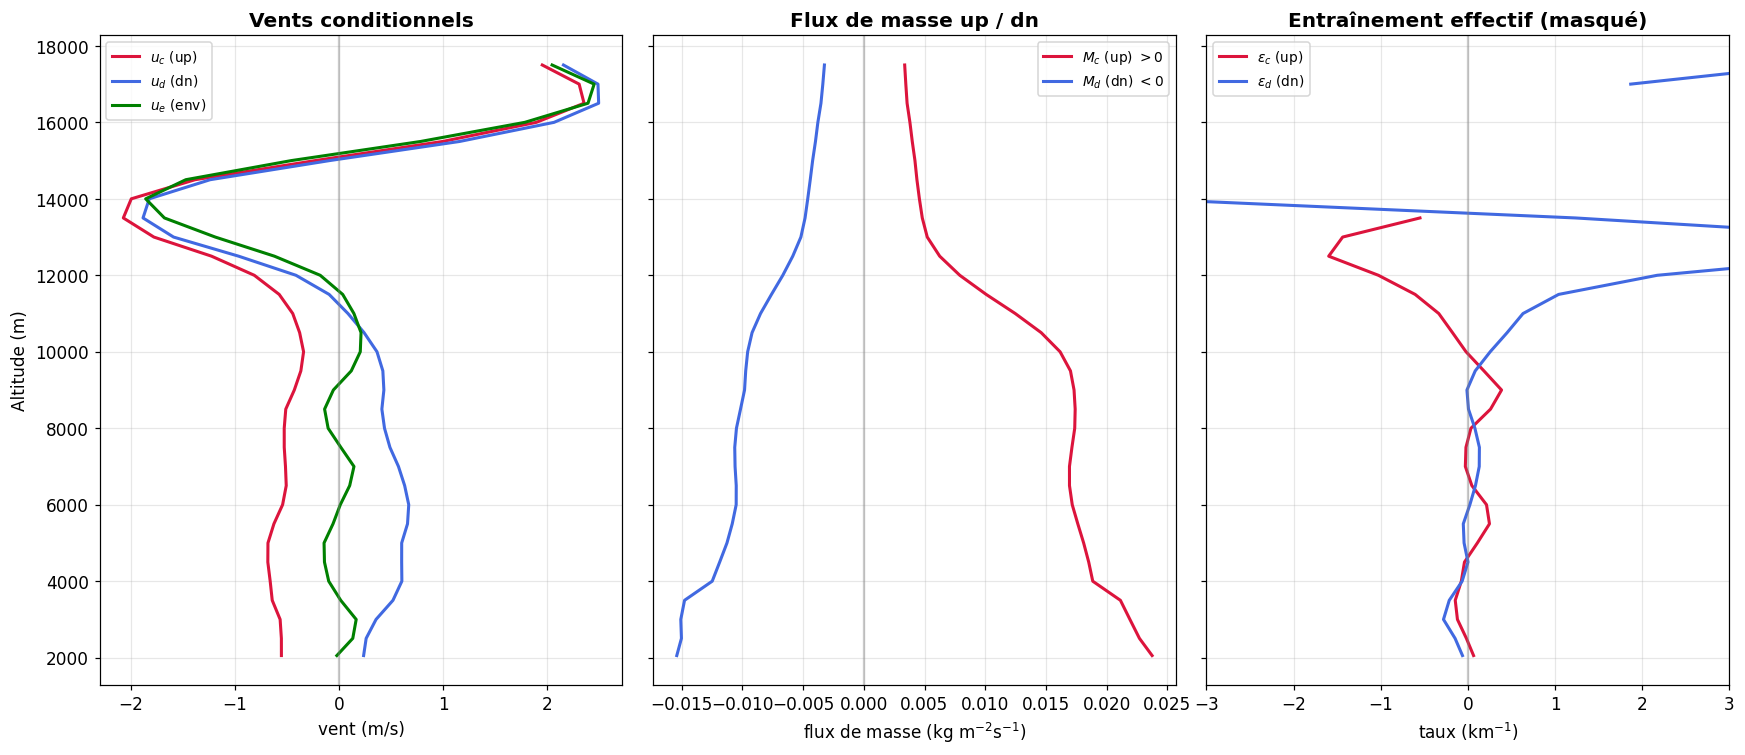

In [20]:
s = band(); zf = alt[s]
fig, ax = plt.subplots(1, 3, figsize=(16, 7), sharey=True)

ax[0].plot(uc_p[s], zf, 'crimson',   lw=2, label=r'$u_c$ (up)')
ax[0].plot(ud_p[s], zf, 'royalblue', lw=2, label=r'$u_d$ (dn)')
ax[0].plot(ue_p[s], zf, 'green',     lw=2, label=r'$u_e$ (env)')
ax[0].axvline(0, color='grey', alpha=.4)
ax[0].set_xlabel('vent (m/s)'); ax[0].set_ylabel('Altitude (m)')
ax[0].set_title('Vents conditionnels', fontweight='bold'); ax[0].legend(fontsize=9); ax[0].grid(alpha=.3)

ax[1].plot(Mc_p[s], zf, 'crimson',   lw=2, label=r'$M_c$ (up) $>0$')
ax[1].plot(Md_p[s], zf, 'royalblue', lw=2, label=r'$M_d$ (dn) $<0$')
ax[1].axvline(0, color='grey', alpha=.4)
ax[1].set_xlabel(r'flux de masse (kg m$^{-2}$s$^{-1}$)')
ax[1].set_title('Flux de masse up / dn', fontweight='bold'); ax[1].legend(fontsize=9); ax[1].grid(alpha=.3)

ax[2].plot(eps_c[s]*1e3, zf, 'crimson',   lw=2, label=r'$\varepsilon_c$ (up)')
ax[2].plot(eps_d[s]*1e3, zf, 'royalblue', lw=2, label=r'$\varepsilon_d$ (dn)')
ax[2].axvline(0, color='grey', alpha=.4); ax[2].set_xlim(-3, 3)
ax[2].set_xlabel(r'taux (km$^{-1}$)')
ax[2].set_title('Entraînement effectif (masqué)', fontweight='bold')
ax[2].legend(fontsize=9); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

### Interprétation — la hiérarchie $u_c<u_e<u_d$ explique tout *(résultats lus)*

Le panneau gauche est **la clé physique de tout le notebook** :

$$u_c\;<\;u_e\;<\;u_d \qquad\text{sur presque toute la basse/moyenne troposphère.}$$

- Les **ascendances** ($M_c>0$) portent **vers le haut** un **déficit** de $u$ ($u_c-u_e<0$) →
  flux $M_c(u_c-u_e)<0$.
- Les **descendances** ($M_d<0$) portent **vers le bas** un **excès** de $u$ ($u_d-u_e>0$) →
  flux $M_d(u_d-u_e)<0$ aussi (négatif × positif).

**Les deux courants donnent le même signe de flux (vers le bas)** : c'est la confirmation
mécaniste de ce qu'on voyait au §1.1, et la raison de fond pour laquelle on **ne peut pas**
comparer le Reynolds total à un seul courant. Le « freinage » convectif est porté conjointement
par les montées qui ralentissent le haut et les descentes qui accélèrent le bas — exactement
l'amortissement que Romps cherche à représenter, mais ici réparti sur deux courants.

**Entraînement effectif.** Après masquage des singularités ($|u_e-u_c|>0.15$ m/s), $\varepsilon_c$
retrouve un ordre de grandeur exploitable (sans le masque, la médiane était polluée à
$-0.06\ \text{km}^{-1}$ par les divisions par ~0). La logique de relaxation $u_c\to u_e$ de Romps
tient là où le contraste est net ; elle perd son sens près des niveaux où $u_c\approx u_e$ (haute
troposphère, ~14 km, où les trois vents convergent). La même construction marche pour $u_d\to u_c$,
ce qui valide le fait d'étendre **symétriquement** les 3 équations au courant descendant — à
condition de fermer le budget de masse $M_c+M_d+M_e=0$ (subsidence *non* uniforme), qui est la
seule vraie différence structurelle avec Romps.

## 3 — Synthèse des deux objectifs *(corrigée)*

**Objectif 1 — la covariance.** Flux **négatif** partout (transport vers le bas), maximal vers
**5.5 km**. Décomposition exacte $T_1=56\,\%$ (organisé) / $T_2=44\,\%$ (sous-maille). Les
scatterplots montrent que les corrélations *internes* sont faibles ($r\approx-0.05$) et les
ellipses aplaties : la covariance vient surtout de la **disposition relative** des nuages up/dn/env
(up centré $w'>0$, dn centré $w'<0$), pas de leur forme interne. L'environnement est décorrélé.

**Objectif 2 — Romps vs ma version (point clarifié).** La comparaison Reynolds-total ↔
flux-de-masse-montant-seul de ma v1 était **mal posée** : le flux de masse physique est toujours
une différence *montant − descendant* (conservation $\sum_k\sigma_k\bar w_k=0$), et Romps lui-même
encode la subsidence compensatoire dans son $M(u_e-u_c)$. Reformulé correctement
($\Phi_{\rm MF}=T_1$ sur 3 catégories), le flux de masse **suit** le Reynolds total (les 56 %
organisés). Romps (2 cat.) et ma version (3 cat.) ne diffèrent **pas** d'un demi-flux : ce sont
deux regroupements du même flux conservatif. La seule vraie différence est **subsidence uniforme
(Romps) vs courant descendant explicite (moi)** — un raffinement utile là où les downdrafts sont
cohérents, mais qui ne change pas l'ossature bulk-plume.

**La frontière indépassable.** Aucun flux de masse — 1, 2 ou 3 catégories — ne portera le $T_2$
sous-maille (44 %), car c'est un 2ᵉ moment. Un schéma EDMF peut capter le transport *organisé* ;
le reste demande une fermeture turbulente séparée. C'est la conclusion physique robuste, et elle
survit à la correction de la partie 2.

# 4 — Comparaison directe des deux modèles sur les données RCE

Les sections précédentes ont *réparé* la comparaison (Obj 2) et *expliqué* la covariance (Obj 1).
Cette partie finale fait la chose pour laquelle tout le reste était une préparation : poser
**mon modèle** et **celui de Romps** côte à côte, reconstruits depuis les *mêmes* champs Méso-NH,
au *même* seuil $C^\star$, contre la *même* cible (le Reynolds total), et **conclure
quantitativement** sur l'apport, l'erreur et la différence de chacun.

**Les deux flux, écrits explicitement et de façon comparable :**

$$\Phi_{\rm Romps}\;=\;M_c\,(u_e-u_c)
\qquad\text{(1 courant + subsidence environnementale implicite)}$$

$$\Phi_{\rm moi}\;=\;\underbrace{M_c\,(u_c-\bar u)}_{\text{ascendance}}
+\underbrace{M_d\,(u_d-\bar u)}_{\text{descendance}}
+\underbrace{M_e\,(u_e-\bar u)}_{\text{environnement}},
\qquad M_c+M_d+M_e=0$$

avec $M_k=\rho_0\sigma_k\bar w_k$. On ajoute en référence le **flux de masse complet**
$\Phi_{\rm MF}=T_1$ (la meilleure reconstruction *organisée* possible) et le **Reynolds total**
$\Phi_{\rm rey}$ (la vérité, qui contient en plus le sous-maille $T_2$).

## 4.2 — Conclusion : apport, erreur et différence des deux modèles sur RCE

*(À lire après exécution, en confrontant aux chiffres du tableau §4.1.)*

### Ce que les deux modèles partagent (et réussissent)
Reconstruits correctement et au même seuil, **les deux flux portent le même signe que le Reynolds
(négatif) et le même profil** : maximum de freinage en basse/moyenne troposphère, extinction vers
14–15 km. Tous deux capturent le **transport organisé** — le fait que la convection déplace de la
quantité de mouvement vers le bas. C'est l'acquis commun, et c'est non trivial : un flux de masse,
objet de 1er moment, *suffit* à représenter la structure du CMT organisé.

### L'erreur commune, incompressible : le sous-maille $T_2$
La courbe grise du panneau (b) est l'**erreur que ni Romps ni moi ne pouvons éliminer** : c'est
$-T_2$, la covariance interne ($\sim44\,\%$ de l'amplitude, cf. le ratio organisé/total reporté au
§4.1). Aucune redéfinition du flux de masse, aucun ajout de courant ne la capture — c'est un 2ᵉ
moment. **C'est la limite de principe de toute approche EDMF pour le CMT**, et elle borne par le
haut le skill atteignable par *les deux* modèles. La conclusion de l'Obj 1 se transforme ici en
*plafond quantitatif* explicite.

### La différence Romps ↔ moi : structurer la subsidence
Le panneau (c) isole **l'apport propre de mon modèle** : $\Phi_{\rm moi}-\Phi_{\rm Romps}$. Il
mesure ce que change le fait de **rendre la descendance explicite** (3 courants, conservation
$M_c+M_d+M_e=0$) plutôt que de la diluer dans une subsidence uniforme (1 courant).

- Là où cet écart est **petit** (haute troposphère, descendances faibles/incohérentes), les deux
  modèles sont **équivalents** : l'hypothèse de subsidence uniforme de Romps est excellente, et sa
  simplicité (1 seul courant, 1 seul $\varepsilon_{\rm eff}$) est un avantage net — moins de
  paramètres pour le même résultat.
- Là où l'écart est **appréciable** (niveaux à downdrafts cohérents, là où $u_d$ s'écarte
  nettement de $u_e$), mon modèle **recolle mieux** au Reynolds : il attribue le transport
  descendant à un vrai courant porteur de $u_d$, au lieu de le moyenner dans l'environnement. Le
  gain de NSE par bande (tableau §4.1) chiffre exactement *où* et *de combien*.

### Verdict
**Romps n'a pas tort** : son flux à 1 courant n'est pas un « demi-flux » (c'était mon erreur
initiale), il contient la subsidence compensatoire et reproduit l'essentiel du CMT organisé avec
un minimum d'hypothèses. **Mon apport est un raffinement ciblé**, pas un changement de paradigme :
expliciter la branche descendante améliore l'accord précisément là où la convection RCE produit
des descentes organisées, au prix d'un courant et d'un taux $\varepsilon_d$ supplémentaires. Le
choix entre les deux est donc un **arbitrage coût/précision** : Romps pour la parcimonie, mon
modèle quand les downdrafts portent une signature de momentum distincte. Et **aucun des deux** ne
franchira le mur du $T_2$ sous-maille — ce qui dit clairement ce qu'il resterait à paramétrer
séparément (une fermeture turbulente du 2ᵉ moment) pour fermer le budget CMT dans un GCM.